In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sklearn
import warnings
from statsmodels.discrete.discrete_model import Logit
from scipy.special import logit
warnings.filterwarnings('ignore')

plt.rcParams["figure.figsize"] = (6, 3)

In [ ]:
import pandas as pd

df=pd.read_csv('/content/drive/MyDrive/census.csv')
#df=pd.read_csv('/content/drive/MyDrive/Group 11/data/census.csv')
# Review counts and data types 
print(df.info())

# Display first 5 rows from original dataset
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
# Part 1: Data Handling

# Rename columns that contain dashes to contain underscores instead
df.rename(columns={"education-num": "education_num", "marital-status": "marital_status",
                   "capital-gain":"capital_gain","capital-loss":"capital_loss",
                   "hours-per-week":"hours_per_week","native-country":"native_country"},
          inplace=True)

In [ ]:
# Display all unique values per columns
for v, col in enumerate(df.columns):
  print(df.columns[v], ':\n', df[str(col)].unique(), '\n')

age :
 [25 38 28 44 18 34 29 63 24 55 65 36 26 58 48 43 20 37 40 72 45 22 23 54
 32 46 56 17 39 52 21 42 33 30 47 41 19 69 50 31 59 49 51 27 57 61 64 79
 73 53 77 80 62 35 68 66 75 60 67 71 70 90 81 74 78 82 83 85 76 84 89 88
 87 86] 

workclass :
 ['Private' 'Local-gov' '?' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked'] 

fnlwgt :
 [226802  89814 336951 ... 129912 255835 257302] 

education :
 ['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' 'Doctorate' '5th-6th' 'Assoc-voc' '9th'
 '12th' '1st-4th' 'Preschool'] 

education_num :
 [ 7  9 12 10  6 15  4 13 14 16  3 11  5  8  2  1] 

marital_status :
 ['Never-married' 'Married-civ-spouse' 'Widowed' 'Divorced' 'Separated'
 'Married-spouse-absent' 'Married-AF-spouse'] 

occupation :
 ['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' '?'
 'Other-service' 'Prof-specialty' 'Craft-repair' 'Adm-clerical'
 'Exec-managerial' 'Tech-support' 'Sales

In [ ]:
# Replace "?" with NaN for all rows
df.replace("?", np.nan, inplace = True)

# Drop all rows with NaN values
df=df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 45222 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   fnlwgt          45222 non-null  int64 
 3   education       45222 non-null  object
 4   education_num   45222 non-null  int64 
 5   marital_status  45222 non-null  object
 6   occupation      45222 non-null  object
 7   relationship    45222 non-null  object
 8   race            45222 non-null  object
 9   sex             45222 non-null  object
 10  capital_gain    45222 non-null  int64 
 11  capital_loss    45222 non-null  int64 
 12  hours_per_week  45222 non-null  int64 
 13  native_country  45222 non-null  object
 14  income          45222 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.5+ MB


In [ ]:
# Map '<=50K' and '>50K' values from "income" column in to 0 or 1 in "income_num" column
df['income_num']=df['income'].map({'<=50K':0, '>50K':1})

# Map 'Male' and 'Female' values from "sex" column in to 0 or 1 in "sex_num" column
df['sex_num']=df['sex'].map({'Male':0, 'Female':1})


In [ ]:
# Create a new field, age_group, to bin ages:

df.loc[df['age'] < 20, "age_group"] = 'Teenager'
df.loc[(df['age'] >= 20) & (df['age'] < 40), "age_group"] = 'Young Adult'
df.loc[(df['age'] >= 40) & (df['age'] < 65), "age_group"] = 'Middle Age'
df.loc[(df['age'] >= 65), "age_group"] = 'Senior'

# Create a new field, employment_type, to bin hours-per-week:

df.loc[df['hours_per_week'] < 30, "employment_type"] = 'Part Time'
df.loc[(df['hours_per_week'] >= 30) & (df['hours_per_week'] < 40), "employment_type"] = 'Full Time'
df.loc[(df['hours_per_week'] >= 40), "employment_type"] = 'Over Employed'
        
# Create a new field, region, to bin native-country (~44K are US):

df.loc[(df['native_country'] == 'United-States'), "region"] = 'US'
df.loc[(df['native_country'] != 'United-States'), "region"] = 'Non-US'

# Map these to 0 and 1
df['region_num']=df['region'].map({'US':0, 'Non-US':1})

# Update occupation to "None" where workclass = 'Never-worked'

df.loc[(df['workclass'] == '?'), 'occupation'] = 'None'
df.loc[df['workclass'] == '?']
       
# Add a net capital gain column
df['net_capital_gain'] = df['capital_gain'] - df['capital_loss']


In [ ]:
# Seth: Adding some of Abelard's transformations here as well
# Create 'is_gov_work' column
df['is_gov_work'] = df['workclass'].map(
        {'Local-gov':1,'Federal-gov':1,'State-gov':1,
         'Private':0,'Self-emp-not-inc':0,'Self-emp-inc':0,
         '?':0,'Without-pay':0,'Never-worked':0})

# Create 'is_priv_work' column
df['is_priv_work'] = df['workclass'].map(
        {'Local-gov':0,'Federal-gov':0,'State-gov':0,
         'Private':1,'Self-emp-not-inc':0,'Self-emp-inc':0,
         '?':0,'Without-pay':0,'Never-worked':0})

# Create 'is_selfemp_work' column
df['is_selfemp_work'] = df['workclass'].map(
        {'Local-gov':0,'Federal-gov':0,'State-gov':0,
         'Private':0,'Self-emp-not-inc':1,'Self-emp-inc':1,
         '?':1,'Without-pay':0,'Never-worked':0})

# Create 'is_other_work' column
df['is_other_work'] = df['workclass'].map(
        {'Local-gov':0,'Federal-gov':0,'State-gov':0,
         'Private':0,'Self-emp-not-inc':0,'Self-emp-inc':0,
         '?':1,'Without-pay':1,'Never-worked':1})

# Rename '?' to 'other'
df.loc[df['workclass'] == '?','workclass'] = 'Other'

# Simplify marital status dimension
df['is_couple'] = df['marital_status'].map(
    {'Married-civ-spouse':1,
     'Never-married':0,
     'Divorced':0,
     'Separated':0,
     'Widowed':0,
     'Married-spouse-absent':0,
     'Married-AF-spouse':1})

# Isolate own child dimension (additional info from marital status and age)
df['own_child'] = df['relationship'].map(
    {'Own-child':1, 
     'Husband':0, 
     'Not-in-family':0, 
     'Unmarried':0, 
     'Wife':0, 
     'Other-relative':0}) 

# Clean up race values
df['race'] = df['race'].map(
    {'Black':'black',
     'White':'white',
     'Asian-Pac-Islander':'asian',
     'Amer-Indian-Eskimo':'native',
     'Other':'other'})

# Apply one hot encoding
race_encode_df = pd.get_dummies(df['race'], prefix='race')
df = pd.concat([df, race_encode_df], axis = 1)

# Clean up occupation values
df['occupation'] = df['occupation'].map(
    {'Machine-op-inspct':'mach_op_inspct',
     'Farming-fishing':'farm_fish',
     'Protective-serv':'protect_srv',
     'Armed-Forces':'armed_forces',
     'Other':'other',
     'Prof-specialty':'prof',
     'Craft-repair':'repair',
     'Adm-clerical':'admin',
     'Exec-managerial':'management',
     'Tech-support':'tech',
     'Sales':'sales',
     'Priv-house-serv':'house_srv',
     'Transport-moving':'trans',
     'Handlers-cleaners':'caretaker'})

# Apply one hot encoding
occu_encode_df = pd.get_dummies(df['occupation'], prefix='occu')
df = pd.concat([df, occu_encode_df], axis = 1)

<Axes: xlabel='is_other_work', ylabel='Percent'>

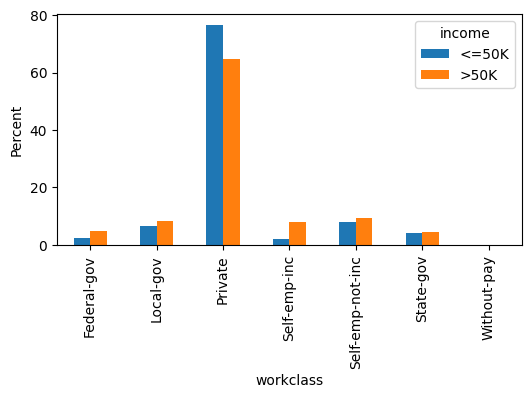

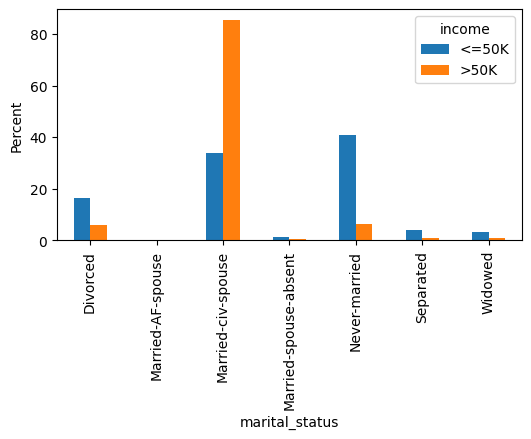

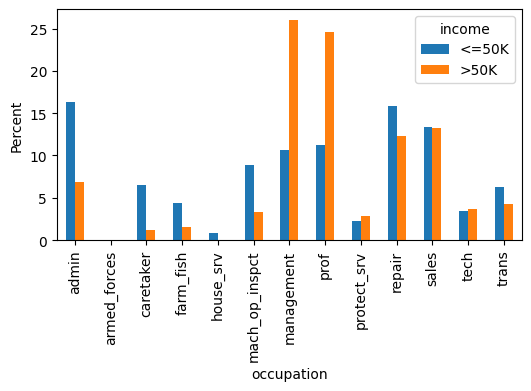

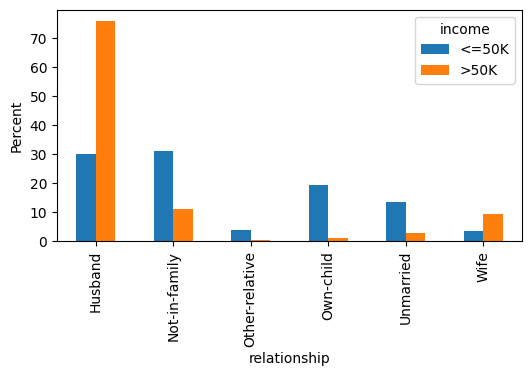

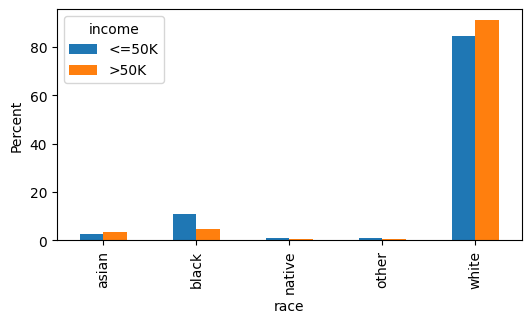

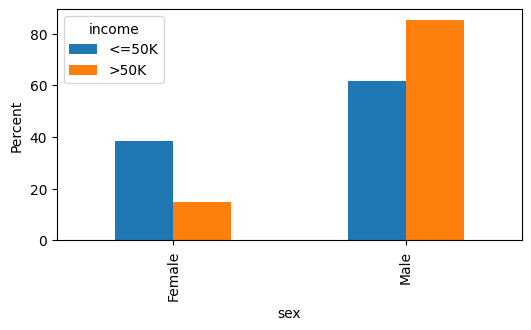

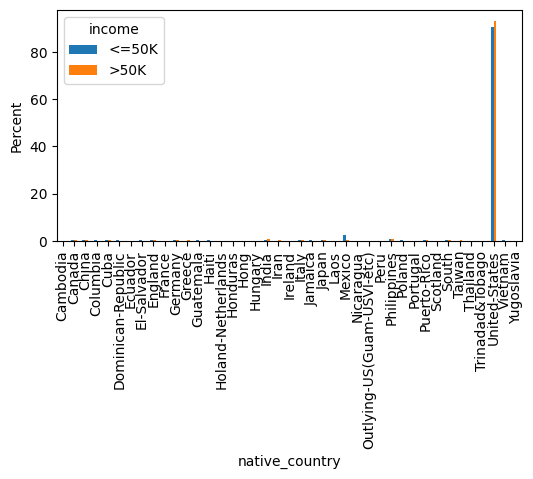

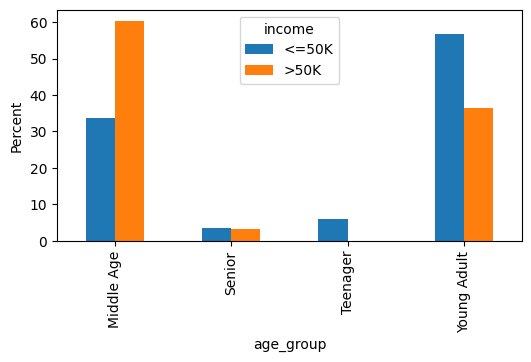

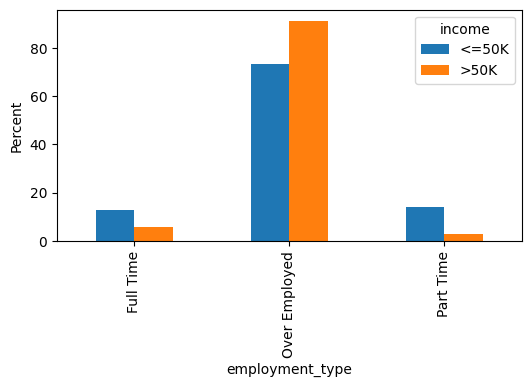

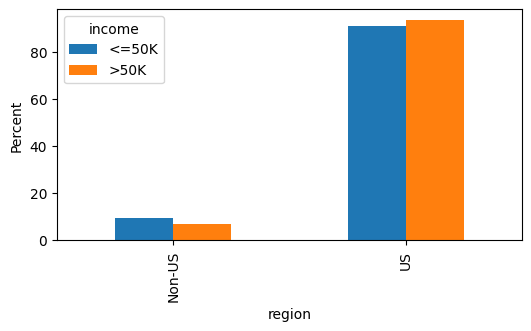

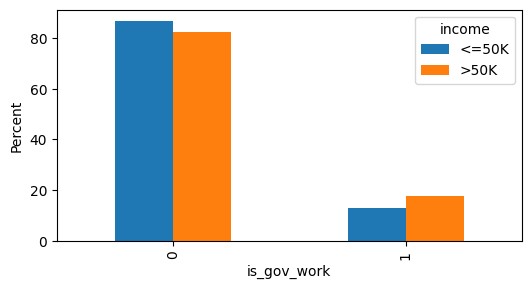

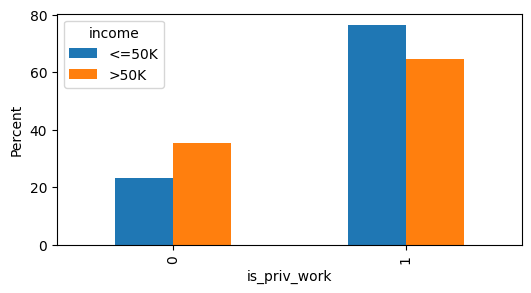

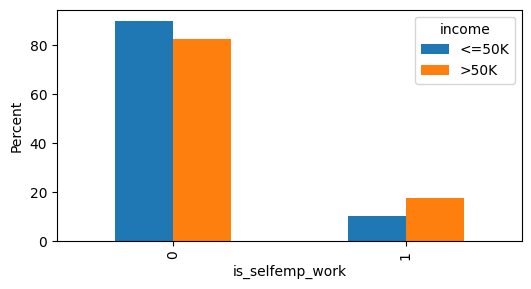

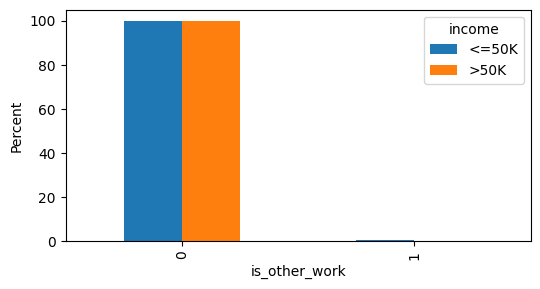

In [ ]:
# Part 2: Data Exploration

# Compare proportions for categorical variables between the two income groups to visually examine if there are significant differences
df.groupby(["income"]).value_counts(['workclass'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')
df.groupby(["income"]).value_counts(['marital_status'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')
df.groupby(["income"]).value_counts(['occupation'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')
df.groupby(["income"]).value_counts(['relationship'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')
df.groupby(["income"]).value_counts(['race'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')
df.groupby(["income"]).value_counts(['sex'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')
df.groupby(["income"]).value_counts(['native_country'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')

# Compare proportions for binned variables - age_group, employment_type, and region
df.groupby(["income"]).value_counts(['age_group'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')
df.groupby(["income"]).value_counts(['employment_type'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')
df.groupby(["income"]).value_counts(['region'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')
df.groupby(["income"]).value_counts(['is_gov_work'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')
df.groupby(["income"]).value_counts(['is_priv_work'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')
df.groupby(["income"]).value_counts(['is_selfemp_work'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')
df.groupby(["income"]).value_counts(['is_other_work'],normalize=True).mul(100).round(1).unstack(0).plot.bar(ylabel='Percent')

In [ ]:
# Compare descriptive statistics for numerical variables between the two income groups
print('Age:\n',df.groupby(["income"]).age.describe())
print('\nFnlwgt:\n',df.groupby(["income"]).fnlwgt.describe())
print('\nEducation_num:\n',df.groupby(["income"]).education_num.describe())
print('\nCapital_gain:\n',df.groupby(["income"]).capital_gain.describe())
print('\nCapital_loss:\n',df.groupby(["income"]).capital_loss.describe())
print('\nHours_per_week:\n',df.groupby(["income"]).hours_per_week.describe())

Age:
           count       mean        std   min   25%   50%   75%   max
income                                                             
<=50K   34014.0  36.749427  13.564683  17.0  26.0  34.0  46.0  90.0
>50K    11208.0  44.006067  10.340502  19.0  36.0  43.0  51.0  90.0

Fnlwgt:
           count           mean            std      min       25%       50%  \
income                                                                       
<=50K   34014.0  190175.214235  106653.659590  13492.0  116968.0  178952.5   
>50K    11208.0  188397.967345  102492.124884  13769.0  118859.0  176775.5   

              75%        max  
income                        
<=50K   239404.75  1490400.0  
>50K    233511.00  1226583.0  

Education_num:
           count       mean       std  min   25%   50%   75%   max
income                                                           
<=50K   34014.0   9.630770  2.420402  1.0   9.0   9.0  10.0  16.0
>50K    11208.0  11.598501  2.367451  1.0  10.0  12.0  13.0 

Seth: Adding some additional data exploration below

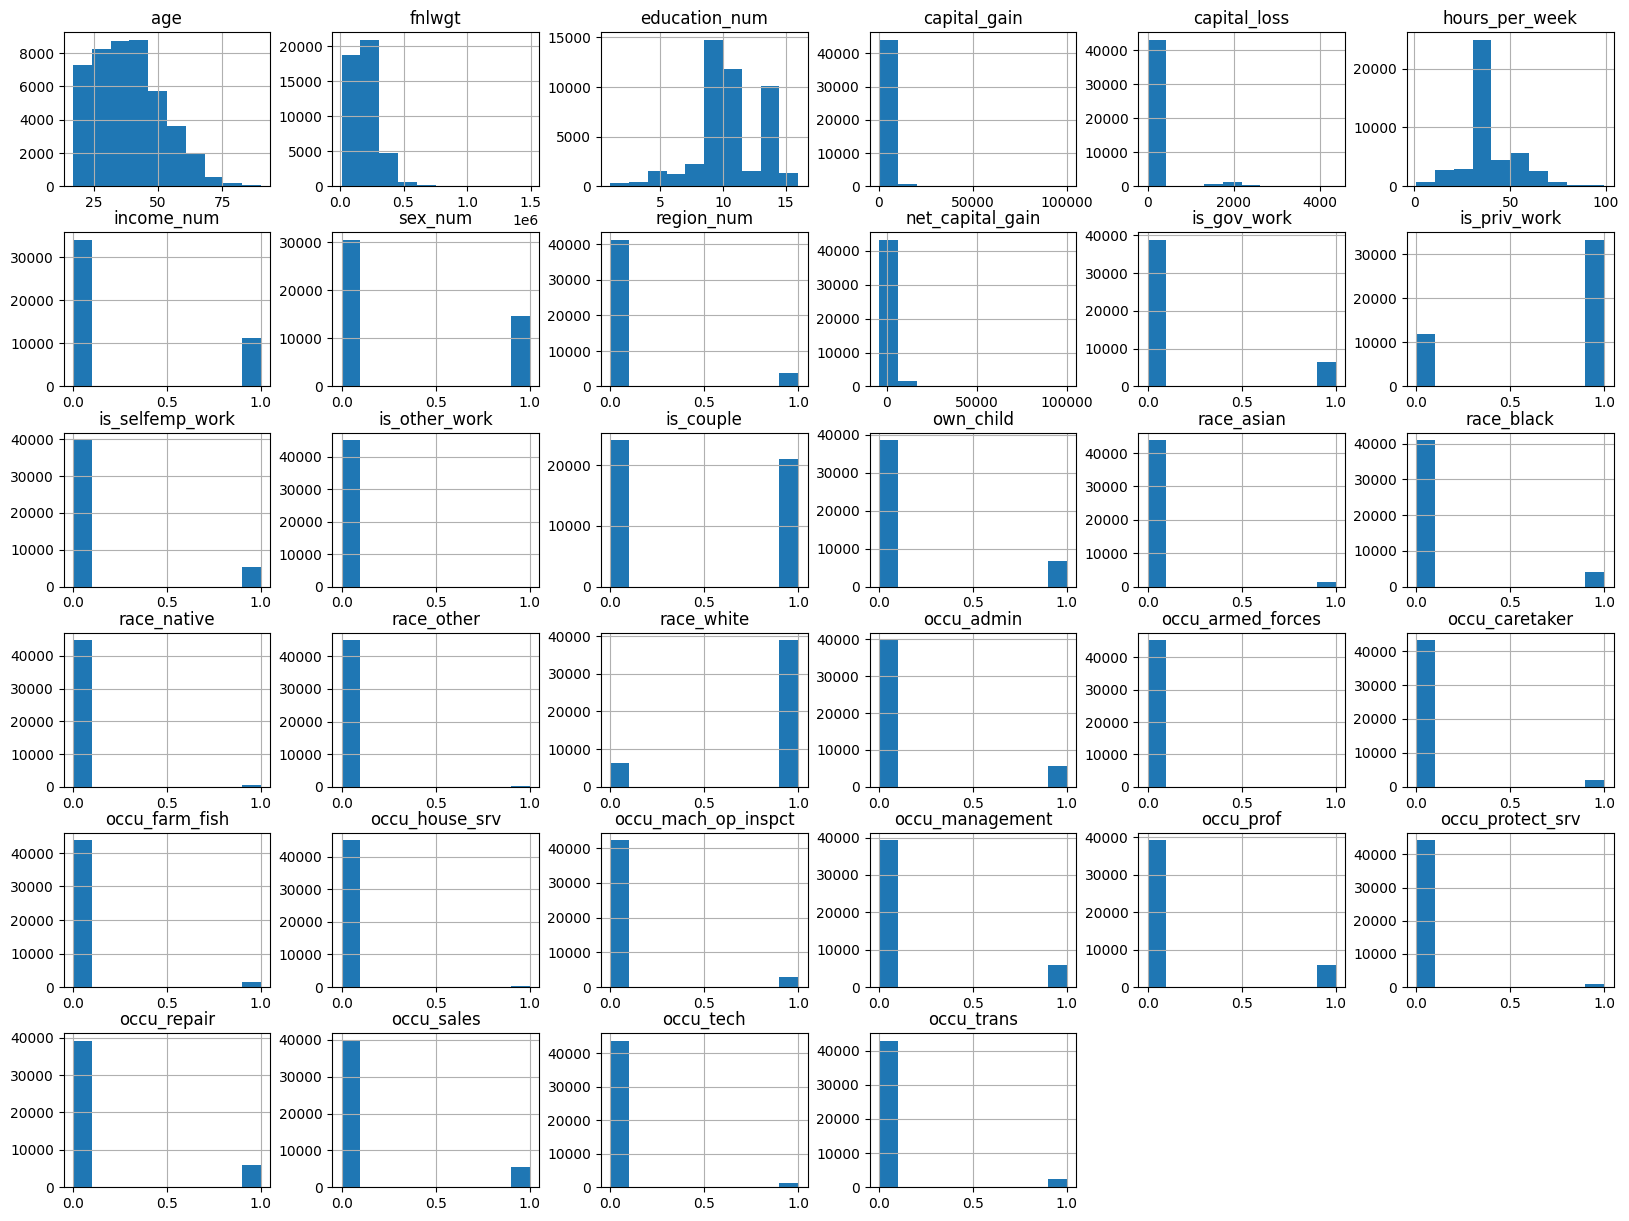

In [ ]:
# Plot the histograms of the individual columns
df.hist(figsize=(20,15))
plt.show()

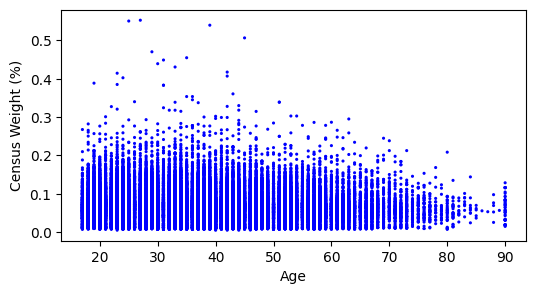

In [ ]:
# Some scatter plots to visualize relationships between numerical columns
# Here I converted the fnlwgt column to percentage of US population in 1996, which has a nicer scale

population1996 = 269700000
plt.scatter(df.age,df.fnlwgt/population1996*100,color='blue',s=5,edgecolor='none')
plt.xlabel('Age')
plt.ylabel('Census Weight (%)')
plt.show()

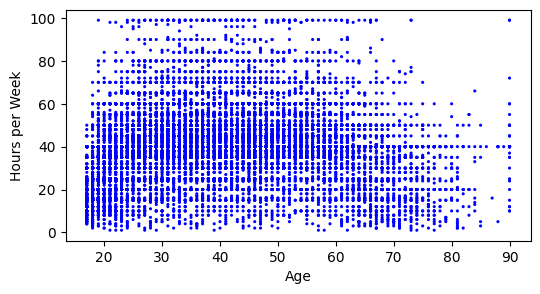

In [ ]:
plt.scatter(df.age,df.hours_per_week,color='blue',s=5,edgecolor='none')
plt.xlabel('Age')
plt.ylabel('Hours per Week')
plt.show()
# Surprising to see 90 year olds working up to 100 hours per week...

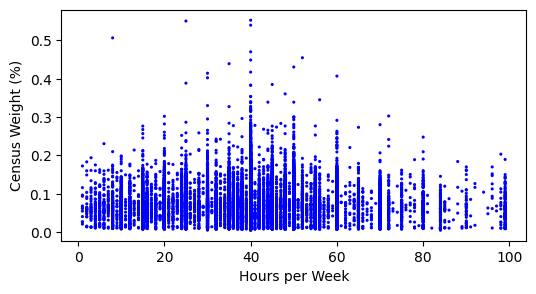

In [ ]:
plt.scatter(df.hours_per_week,df.fnlwgt/population1996*100,color='blue',s=5,edgecolor='none')
plt.ylabel('Census Weight (%)')
plt.xlabel('Hours per Week')
plt.show()

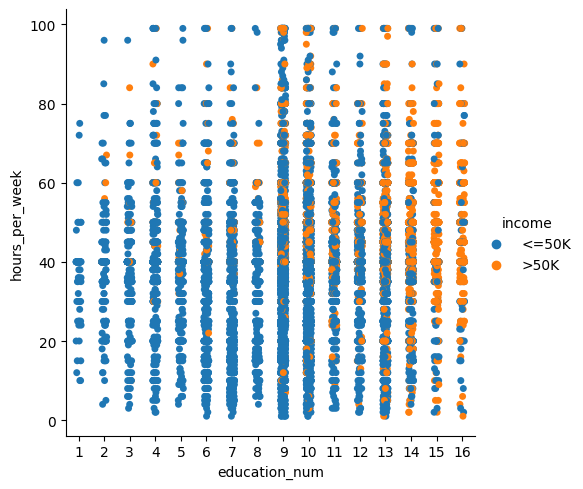

In [ ]:
sns.catplot(data=df,y="hours_per_week", x="education_num", hue="income")
None
# Very clear clustering of 50k+ income in the high education and high hrs per week quadrant

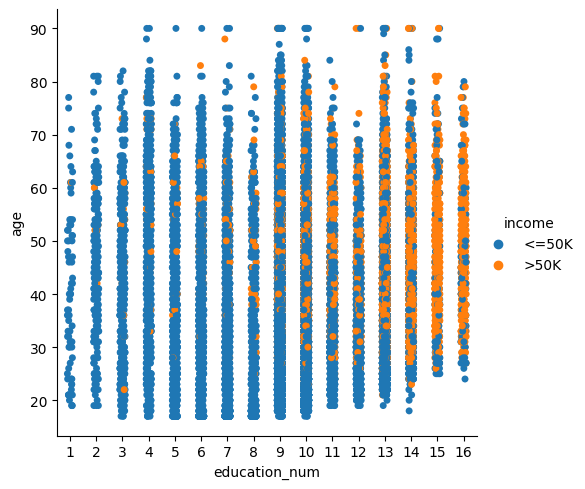

In [ ]:
sns.catplot(data=df,x="education_num", y="age", hue="income")
None
# Education seems to be a stronger predictor than age based on visual inspection

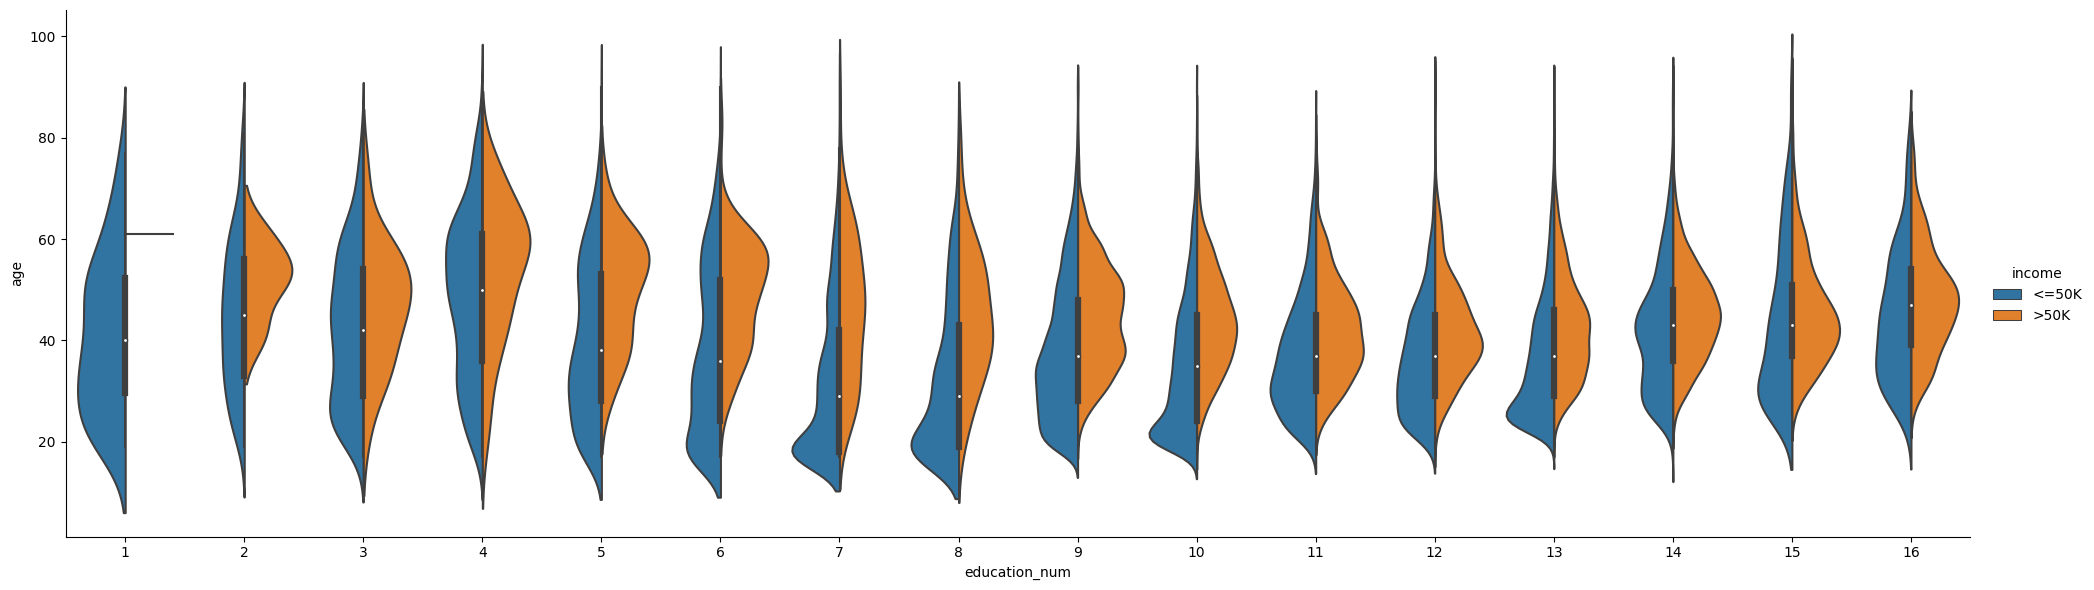

In [ ]:
sns.catplot(
    data=df, x="education_num", y="age", hue="income",
    kind="violin", split=True,height = 6, aspect = 20/6
)
None
# Looking deeper, this relationship is fairly asymmmetric
# Note for higher levels of education, we clearly see <50k income being more prevalent among younger adults
# For lower levels of education, conversely, higher income is associate with higher age

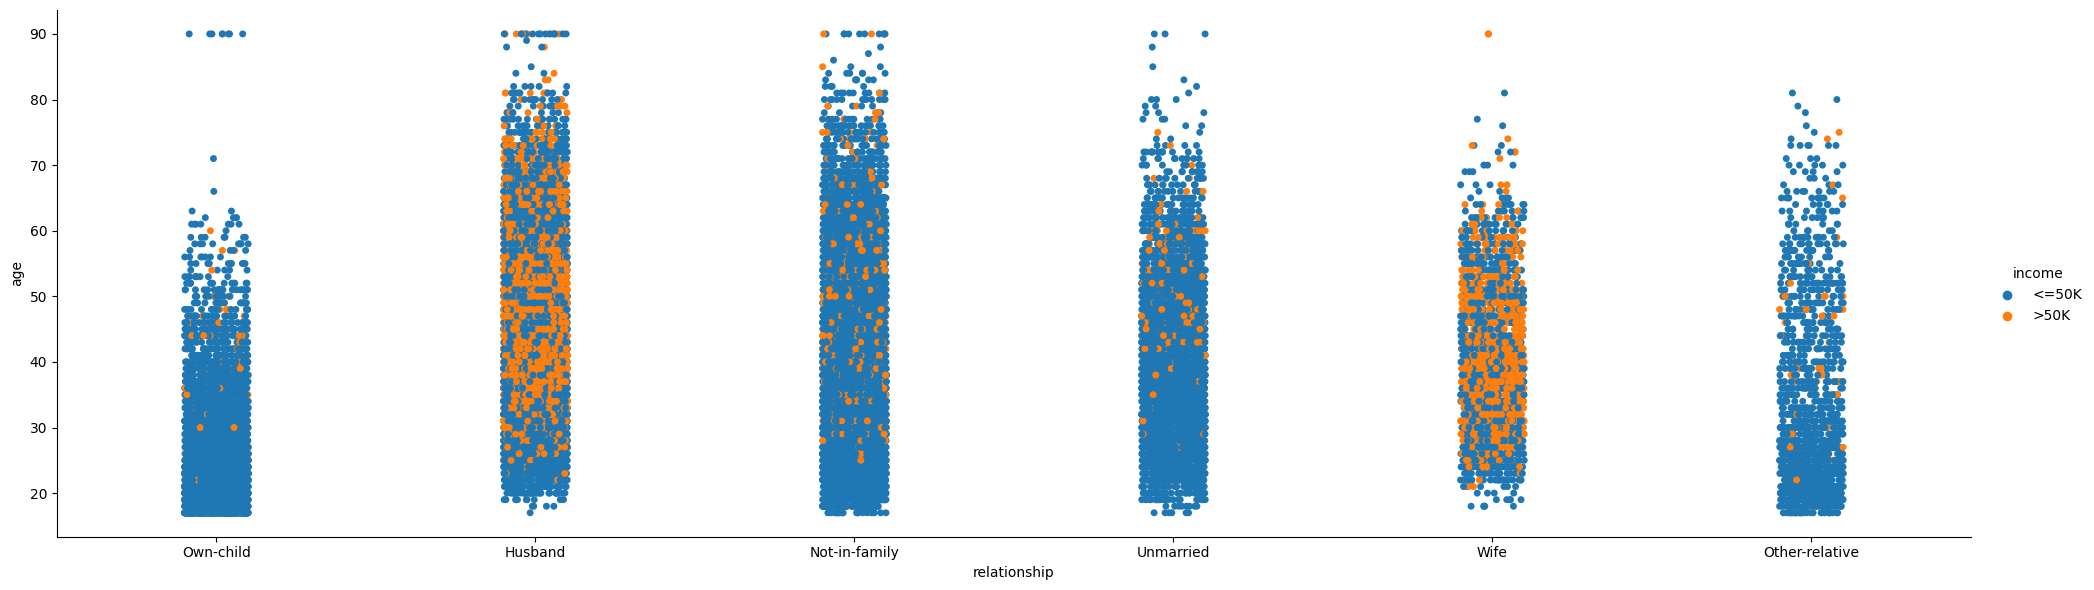

In [ ]:
sns.catplot(data=df,x="relationship", y="age", hue="income",height=6,aspect = 20/6)
None
# We see significantly higher concentration of 50k+ income among married individuals

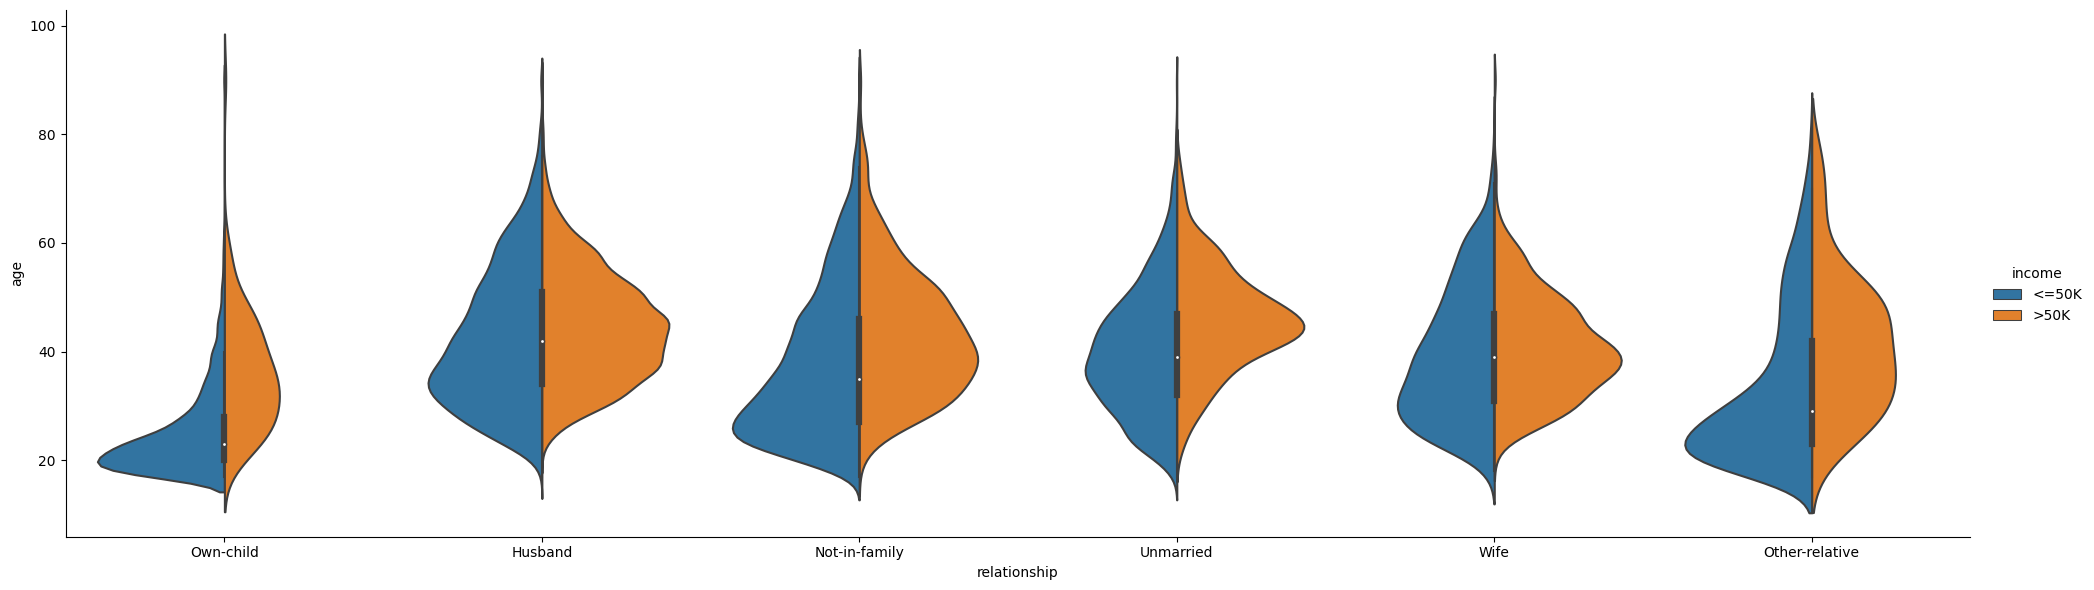

In [ ]:
sns.catplot(
    data=df, x="relationship", y="age", hue="income",
    kind="violin", split=True,height = 6, aspect = 20/6
)
None
# Being young and having a child seems to be a strong predictor of <50k income

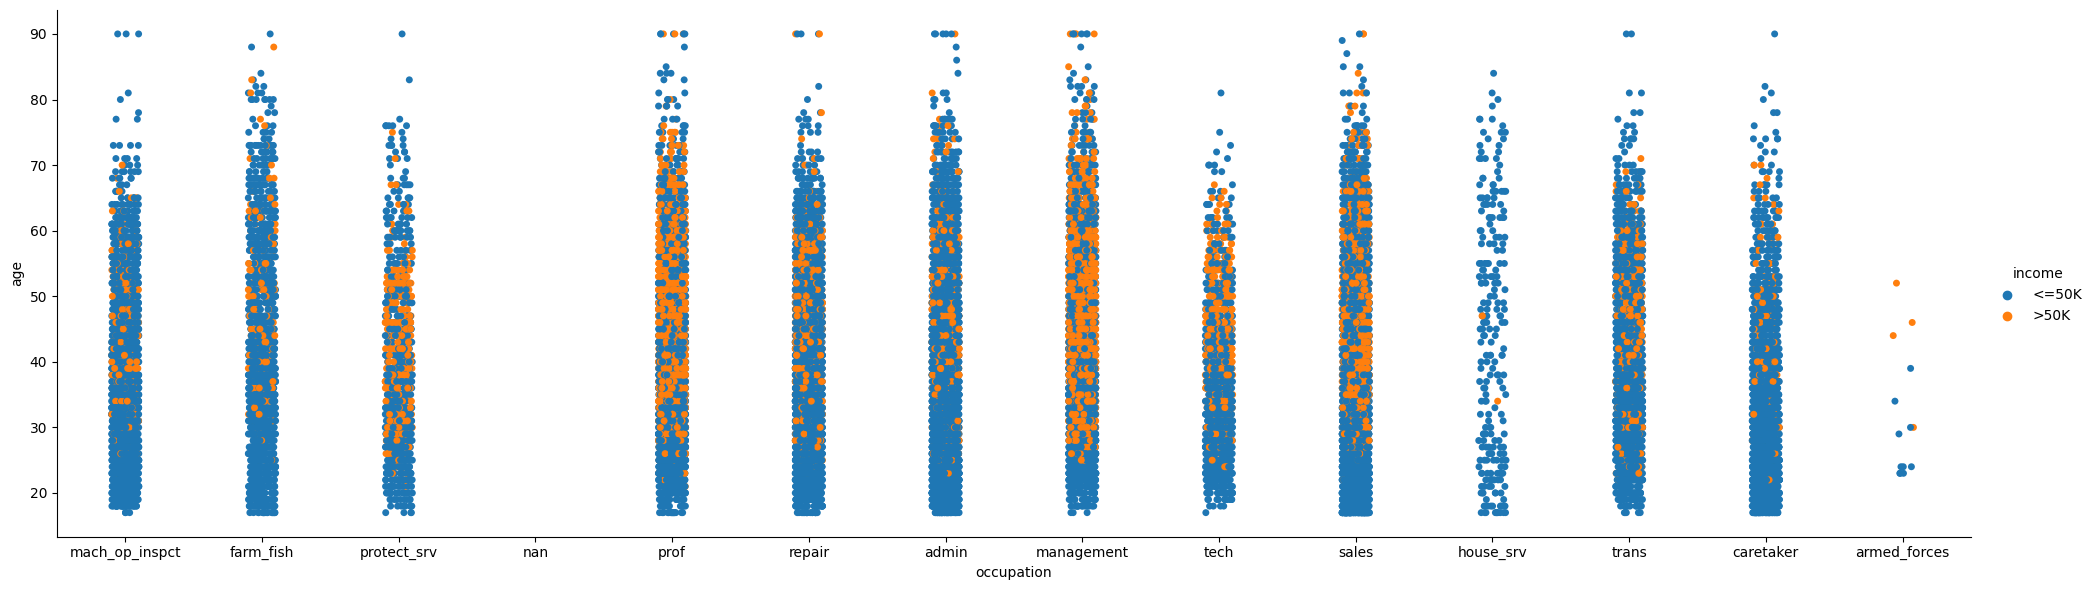

In [ ]:
sns.catplot(data=df,x="occupation", y="age", hue="income",height=6,aspect=20/6)
None
# Income 50k+ is clustering in professional and exec-managerial careers

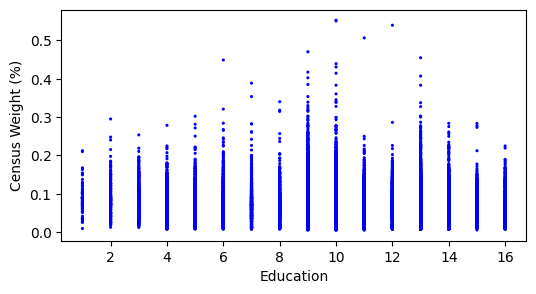

In [ ]:
plt.scatter(df.education_num,df.fnlwgt/population1996*100,color='blue',s=5,edgecolor='none')
plt.xlabel('Education')
plt.ylabel('Census Weight (%)')
plt.show()

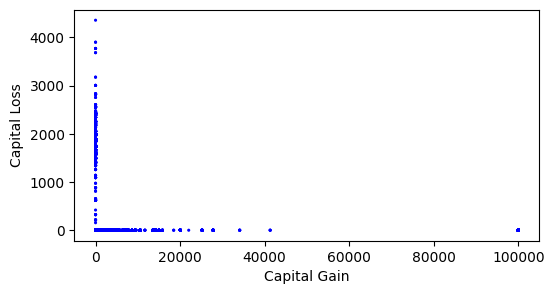

In [ ]:
plt.scatter(df.capital_gain,df.capital_loss,color='blue',s=5,edgecolor='none')
plt.xlabel('Capital Gain')
plt.ylabel('Capital Loss')
plt.show()

In [ ]:
df.head(5)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,...,occu_farm_fish,occu_house_srv,occu_mach_op_inspct,occu_management,occu_prof,occu_protect_srv,occu_repair,occu_sales,occu_tech,occu_trans
0,25,Private,226802,11th,7,Never-married,mach_op_inspct,Own-child,black,Male,...,0,0,1,0,0,0,0,0,0,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,farm_fish,Husband,white,Male,...,1,0,0,0,0,0,0,0,0,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,protect_srv,Husband,white,Male,...,0,0,0,0,0,1,0,0,0,0
3,44,Private,160323,Some-college,10,Married-civ-spouse,mach_op_inspct,Husband,black,Male,...,0,0,1,0,0,0,0,0,0,0
5,34,Private,198693,10th,6,Never-married,NaN,Not-in-family,white,Male,...,0,0,0,0,0,0,0,0,0,0


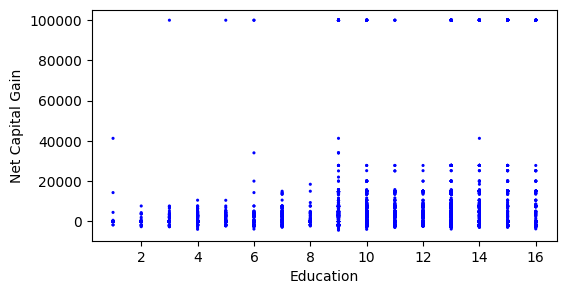

In [ ]:
plt.scatter(df.education_num,df.net_capital_gain,color='blue',s=5,edgecolor='none')
plt.xlabel('Education')
plt.ylabel('Net Capital Gain')
plt.show()

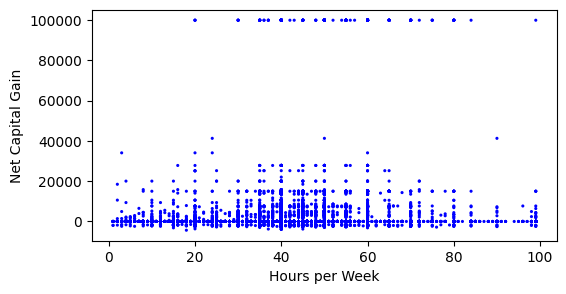

In [ ]:
plt.scatter(df.hours_per_week,df.net_capital_gain,color='blue',s=5,edgecolor='none')
plt.ylabel('Net Capital Gain')
plt.xlabel('Hours per Week')
plt.show()

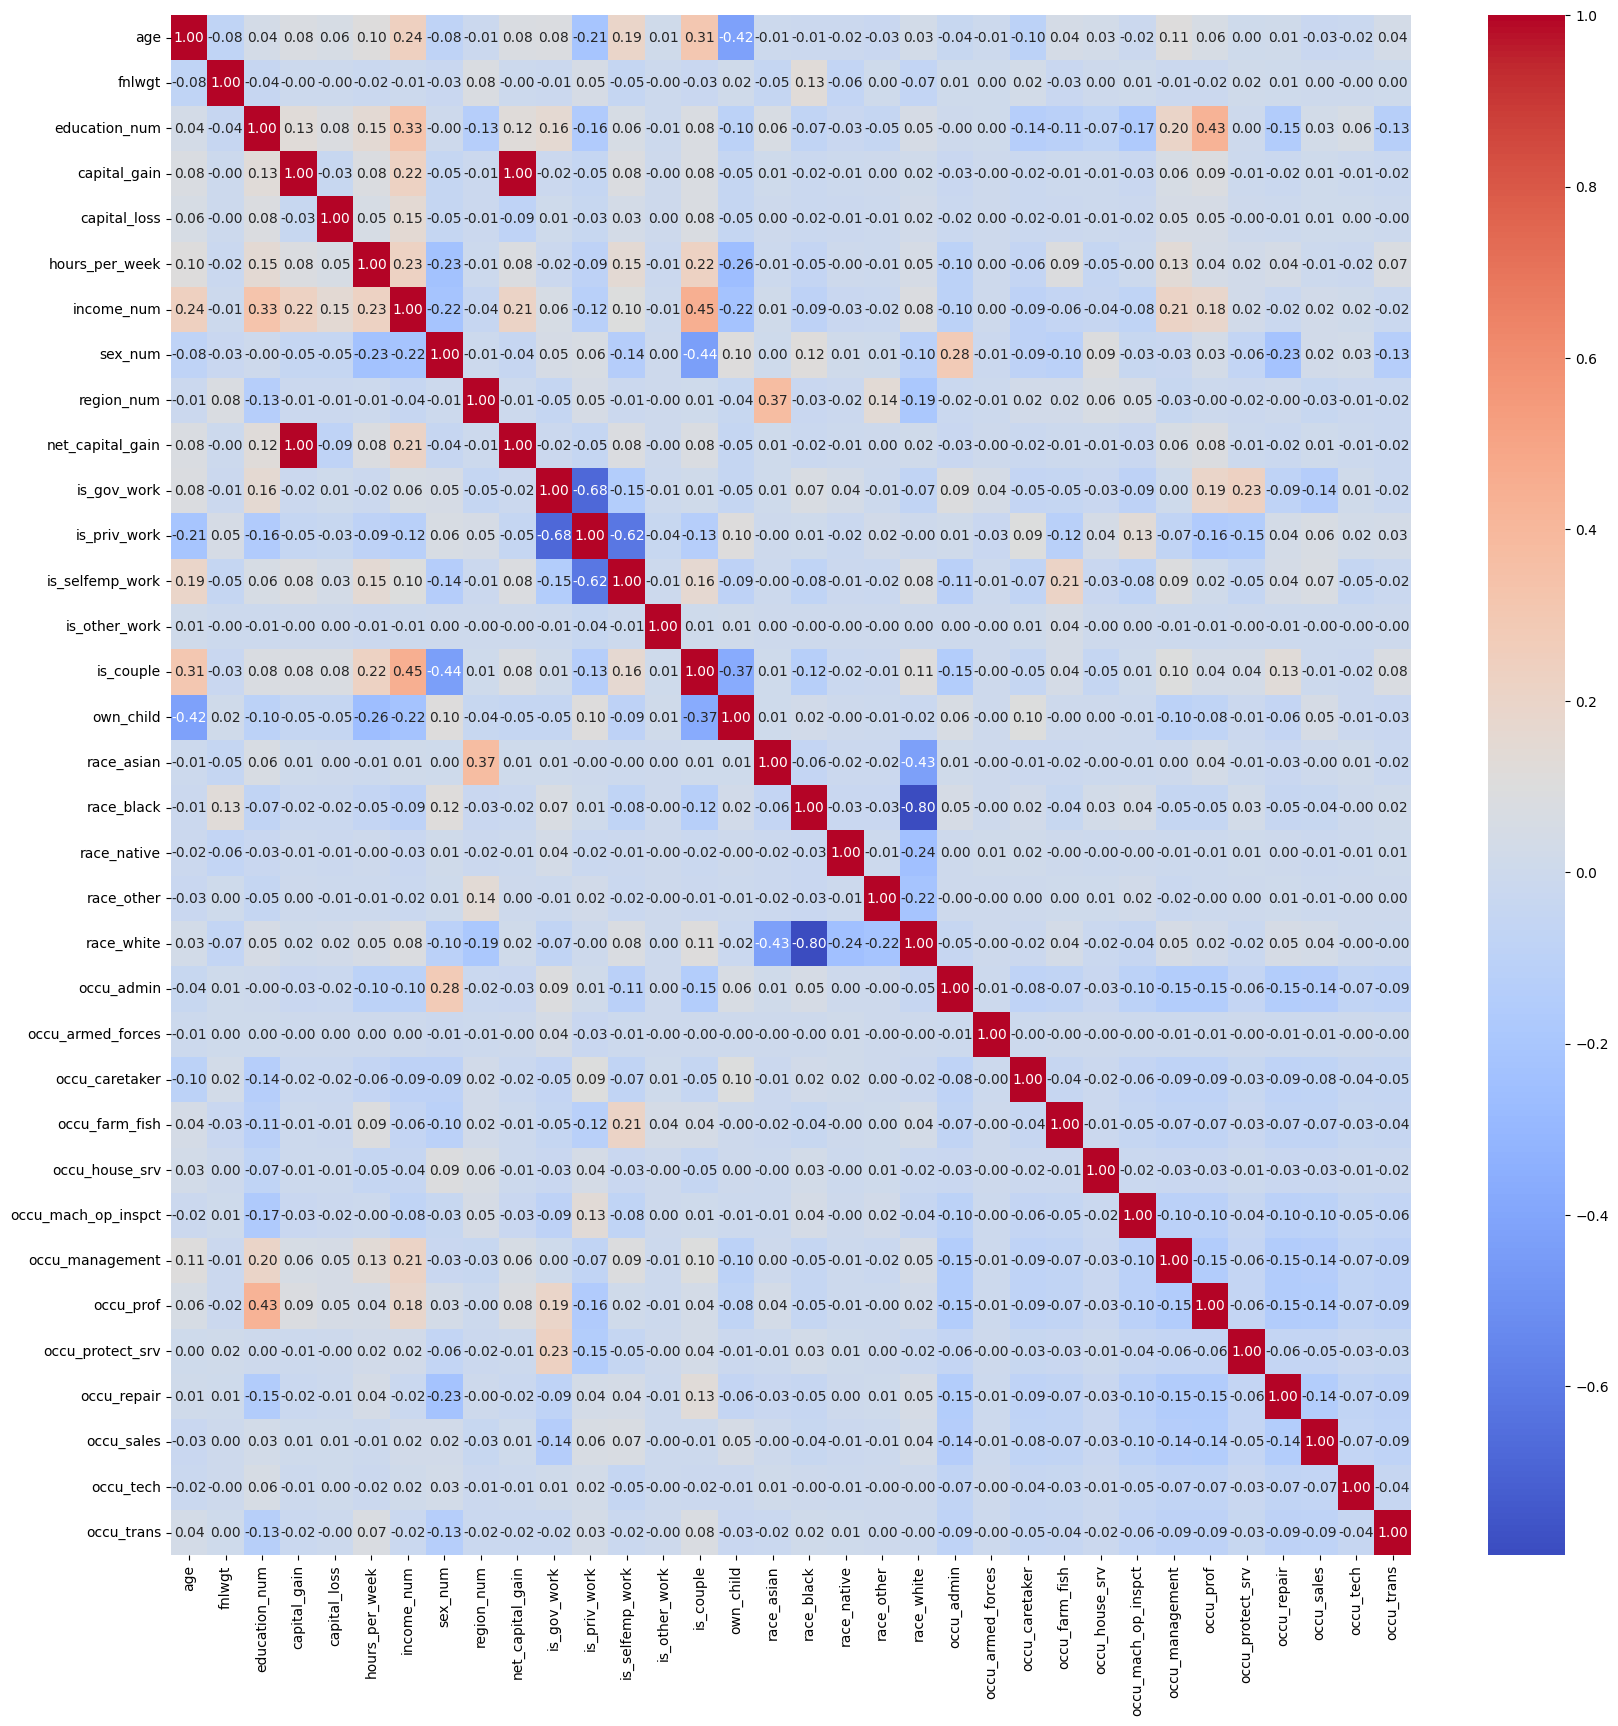

In [ ]:
# Correlation matrix of numerical variables
df_cm = df.corr(method="spearman")
fig, ax = plt.subplots(figsize=(20,20))         # Sample figsize in inches
g = sns.heatmap(df.corr(),annot=True, fmt = ".2f", cmap = "coolwarm",ax=ax)

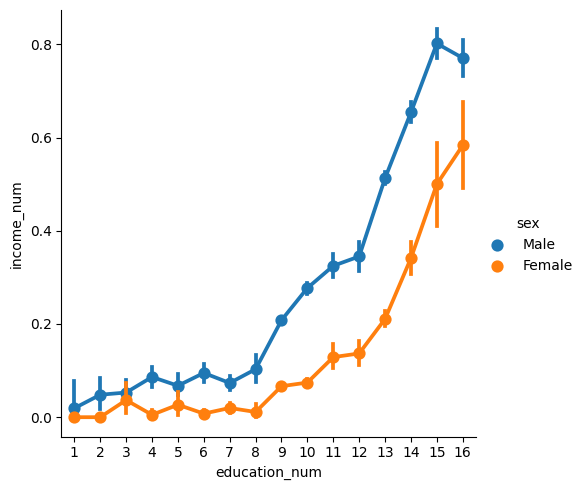

In [ ]:
sns.catplot(data=df, x="education_num", y="income_num", hue="sex", kind="point")
None
# Curious to see to what extent this might have changed since 1996

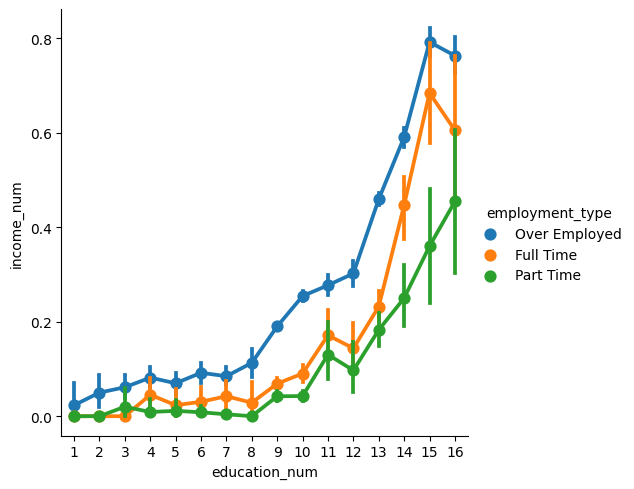

In [ ]:
sns.catplot(data=df, x="education_num", y="income_num", hue="employment_type", kind="point")
None
# Being "overemployed" appears to be a good predictor of income across education levels

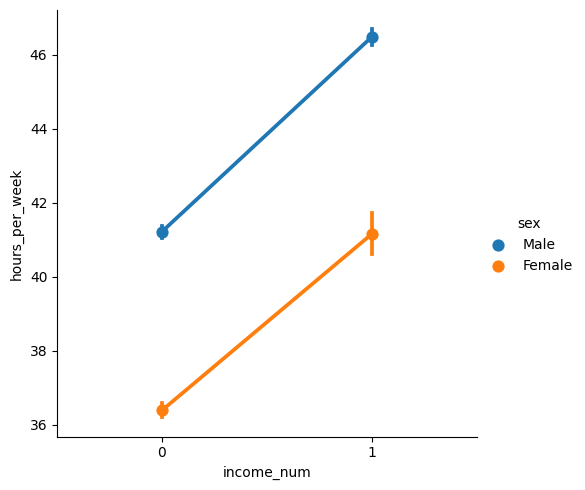

In [ ]:
sns.catplot(data=df, y="hours_per_week", x="income_num", hue="sex", kind="point")
None

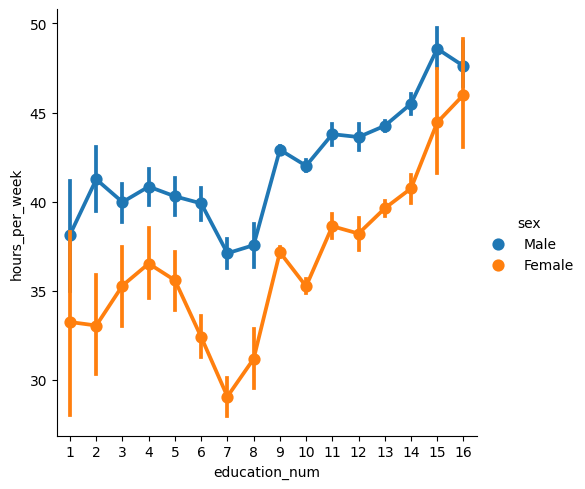

In [ ]:
sns.catplot(data=df, y="hours_per_week", x="education_num", hue="sex", kind="point")
None

In [ ]:
# Part 3: Analysis 
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from statsmodels.discrete.discrete_model import Logit
from scipy.special import logit

# Start with all variables (excluding fnlwgt)
predictors_all=['age','education_num','hours_per_week','sex_num','region_num', 'net_capital_gain', 
                'is_gov_work','is_priv_work', 'is_selfemp_work','is_other_work', 'is_couple', 'own_child', 
                'race_asian','race_black', 'race_native', 'race_other','race_white', 'occu_admin','occu_armed_forces', 
                'occu_caretaker', 'occu_farm_fish','occu_house_srv','occu_mach_op_inspct', 'occu_management', 'occu_prof',
                'occu_protect_srv', 'occu_repair', 'occu_sales', 'occu_tech','occu_trans']

#Check for multicollinearity
print('Collinearity analysis for all variables:')


y=df['income_num']
X=df[predictors_all]
vif_df = pd.DataFrame()
vif_df['variable'] = X.columns 
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_df)

# Removing collinear variables
predictors_clean =['age','education_num','sex_num','region_num', 'net_capital_gain', 
                'is_couple', 'own_child', 'race_asian','race_black', 'race_native', 'race_other',
                'occu_admin','occu_armed_forces','occu_caretaker', 'occu_farm_fish','occu_house_srv',
                'occu_mach_op_inspct', 'occu_management', 'occu_protect_srv', 'occu_repair', 'occu_sales', 'occu_tech','occu_trans']
print('\n')
print('Collinearity analysis after removing selected workclass collinear variables:')                
#Check for multicollinearity after removing collinearity between workclass bins


y=df['income_num']
X=df[predictors_clean]
vif_df = pd.DataFrame()
vif_df['variable'] = X.columns 
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_df)

Collinearity analysis for all variables:
               variable       VIF
0                   age  1.322205
1         education_num  1.565958
2        hours_per_week  1.196608
3               sex_num  1.495555
4            region_num  1.241825
5      net_capital_gain  1.032239
6           is_gov_work       inf
7          is_priv_work       inf
8       is_selfemp_work       inf
9         is_other_work       inf
10            is_couple  1.510356
11            own_child  1.403607
12           race_asian       inf
13           race_black       inf
14          race_native       inf
15           race_other       inf
16           race_white       inf
17           occu_admin  1.974661
18    occu_armed_forces  1.005929
19       occu_caretaker  1.415496
20       occu_farm_fish  1.387391
21       occu_house_srv  1.055671
22  occu_mach_op_inspct  1.570388
23      occu_management  2.277729
24            occu_prof  2.499640
25     occu_protect_srv  1.279564
26          occu_repair  2.174159
27     

In [ ]:
# Logistic Regression from scratch using only numpy ======================================== 1 of 4
class LogisticRegression():
    """This class implements the Logistic Regression Supervised Learning Algorithm from scratch with Numpy only"""
    def __init__(self, num_iter, lr,): # num_iter = 1000, lr = 0.01
        self.num_iter = num_iter     # number of iterations
        self.lr       = lr           # learning rate
        self.w        = None         # weights on each dimension
        self.b        = None         # bias
    
    
    def sigmoid_function(self, y_mx_plus_b):
        return 1 / (1 + np.exp(-y_mx_plus_b))
    
    
    def fit_the_training_set(self, x_train_data, y_train_data):
        num_samples, num_features = x_train_data.shape        
        #print(num_samples, ">>>", num_features)
        self.b = 0
        self.w = np.ones(num_features)
        
        for i in tqdm(range(self.num_iter)):

            z = np.dot(x_train_data, self.w) + self.b
            predicted_y = self.sigmoid_function(z)
            
            # Differentiate the weights to get new weights
            diff_in_w = (1 / num_samples) * np.dot(x_train_data.T, 
                                                   (predicted_y - y_train_data.squeeze()))

            # Differentiate the bias to get new bias
            diff_in_b = (1 / num_samples) * np.sum(predicted_y - y_train_data.squeeze())
            
            # Update the weight values
            # self.__w = self.__w - (self.__lr * diff_in_w)
            self.w -= (self.lr * diff_in_w)
            
            # Update the bias value
            # self.__b = self.__b - (self.__lr * diff_in_b)
            self.b -= (self.lr * diff_in_b)

            
    def make_predictions(self, X_train_data):
        z = np.dot(X_train_data, self.w) + self.b
        predicted_y = self.sigmoid_function(z)

        # Declare an empty list to
        predicted_target_class = []

        # Classify based on make_predictions() returned value
        for each_prediction in predicted_y:
            if(each_prediction > 0.5):
                predicted_target_class.append(1)
            if(each_prediction <= 0.5):
                predicted_target_class.append(0)

        return np.array(predicted_target_class)


In [ ]:
# Logistic Regression from scratch using only numpy ======================================== 2 of 4
!pip install tqdm
from tqdm import tqdm

# Split into training and testing datasets
x_train, x_test, y_train, y_test = train_test_split(df[predictors_clean], df['income_num'], train_size=25000, random_state=1)
df_train = pd.concat([x_train,y_train],axis=1)
df_test = pd.concat([x_test,y_test],axis=1)

"""This implementation assumes that the data is already preprocessed and scaled, 
and that the target variable is binary (0 or 1). To use the class, you can create 
an instance of the LogisticRegression class, and then call the fit method with 
your training data:"""

# X_train-df and y_train-df are your training data
number_of_iterations   = 1000
learning_rate          = 0.01 
log_reg_model = LogisticRegression(number_of_iterations, learning_rate)
log_reg_model.fit_the_training_set(x_train, y_train)
# display(X_train_df.shape, y_train_df.shape, X_test_df.shape, y_test_df.shape)
# log_reg_model.fit_the_training_set(X_train_df, y_train_df)

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


100%|██████████| 1000/1000 [00:11<00:00, 84.53it/s]


In [ ]:
# Logistic Regression from scratch using only numpy ======================================== 3 of 4

"""Now I can call the make_predictions() function to make predictions on new data:"""

# assuming X_test is your test data
print(x_test.shape, y_test.shape)
y_prediction = log_reg_model.make_predictions(x_test)
print(y_prediction)
print("\n==========================================\n")
y_pred_df = pd.DataFrame(y_prediction, columns=['y_prediction']) 
# display(y_pred_df)

print("Number of 1s predicted:", y_prediction.sum())
print("Number of 1s (ground truth):", y_test.sum())

(20222, 23) (20222,)
[0 0 0 ... 0 0 0]


Number of 1s predicted: <class 'numpy.int64'>
Number of 1s (ground truth): <class 'numpy.int64'>


In [ ]:
# Logistic Regression from scratch using only numpy ======================================== 4 of 4

zipped_y = zip(y_prediction, y_test)
total = []
arr = list(zipped_y)
for i in range(len(arr)):
    if(arr[i][0] == arr[i][1]):
        total.append(1)
    else:
        continue

print("Success rate of Logistic Regression using Numpy only : ", (sum(total)/len(arr)) * 100, "%.")

Success rate of Logistic Regression from scratch :  73.82553654435763 %.


In [ ]:
# Split into training and testing datasets
x_train, x_test, y_train, y_test = train_test_split(df[predictors_clean], df['income_num'], train_size=25000, random_state=1)
df_train = pd.concat([x_train,y_train],axis=1)
df_test = pd.concat([x_test,y_test],axis=1)

# Fitting a logistic regression model on the training set
m = Logit(df_train['income_num'],df_train[predictors_clean])
m=m.fit()

#Model Summary
print(m.summary2())

# We see that the model has a pseudo R^2 of 0.28, and the likelyhood function shows improvement over the intercept-only
# model. However, some columns are not statistically significant

Optimization terminated successfully.
         Current function value: 0.400652
         Iterations 8
                           Results: Logit
Model:               Logit             Pseudo R-squared:  0.282     
Dependent Variable:  income_num        AIC:               20078.6116
Date:                2023-04-16 19:24  BIC:               20265.5241
No. Observations:    25000             Log-Likelihood:    -10016.   
Df Model:            22                LL-Null:           -13958.   
Df Residuals:        24977             LLR p-value:       0.0000    
Converged:           1.0000            Scale:             1.0000    
No. Iterations:      8.0000                                         
--------------------------------------------------------------------
                     Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
--------------------------------------------------------------------
age                 -0.0178   0.0013 -13.7384 0.0000 -0.0204 -0.0153
education_num       -0.0185 

In [ ]:
# Remove variables that are not significant
predictors_clean2 =['age','education_num','sex_num','region_num', 'net_capital_gain', 
                'is_couple', 'own_child', 'race_asian','race_black', 'race_native', 'race_other',
                'occu_admin','occu_caretaker', 'occu_farm_fish','occu_house_srv',
                'occu_mach_op_inspct', 'occu_protect_srv', 'occu_repair', 'occu_sales', 'occu_tech','occu_trans']
print('\n')

# Split into training and testing datasets
x_train, x_test, y_train, y_test = train_test_split(df[predictors_clean2], df['income_num'], train_size=25000, random_state=1)
df_train = pd.concat([x_train,y_train],axis=1)
df_test = pd.concat([x_test,y_test],axis=1)

# Fitting a logistic regression model on the training set
m = Logit(df_train['income_num'],df_train[predictors_clean2])
m=m.fit()

#Model Summary
print(m.summary2())
# We see that the R^2 did not change, but now all columns are statistically significant



Optimization terminated successfully.
         Current function value: 0.400695
         Iterations 8
                           Results: Logit
Model:               Logit             Pseudo R-squared:  0.282     
Dependent Variable:  income_num        AIC:               20076.7407
Date:                2023-04-15 23:07  BIC:               20247.4000
No. Observations:    25000             Log-Likelihood:    -10017.   
Df Model:            20                LL-Null:           -13958.   
Df Residuals:        24979             LLR p-value:       0.0000    
Converged:           1.0000            Scale:             1.0000    
No. Iterations:      8.0000                                         
--------------------------------------------------------------------
                     Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
--------------------------------------------------------------------
age                 -0.0176   0.0013 -13.7480 0.0000 -0.0201 -0.0151
education_num       -0.017

In [ ]:
# We analyze the training set using the default threshold of 0.5
# Creating predictions based on model
df_train.loc[:,'p'] = m.predict(df_train[predictors_clean2])
df_train.loc[:,'yhat'] = (df_train.p > 0.5) * 1
df_train.yhat.value_counts()

# Comparing predictions against actual values
print("Training")
print(pd.crosstab(df_train.income_num, df_train.yhat))
print("-------------------------------------\n")


Training
yhat            0     1
income_num             
0           16976  1865
1            3013  3146
-------------------------------------



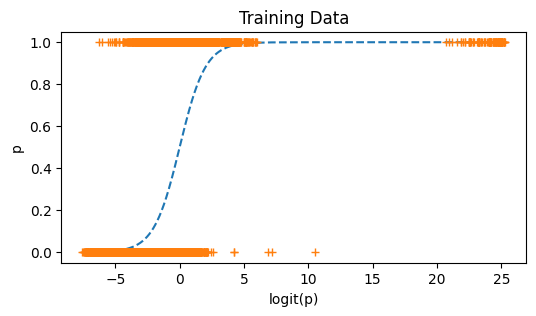

In [ ]:
# Visualize relationship between the 𝐿𝑜𝑔𝑖𝑡(𝑝) and the odds 𝑝  along with the response values
# Training Data
df_train_plot = df_train.sort_values(by = ['p'], axis = 0)
plt.plot(logit(df_train_plot.p), df_train_plot.p, '--')
plt.plot(logit(df_train_plot.p), df_train_plot.income_num, '+')
plt.xlabel('logit(p)')
plt.ylabel('p')
plt.title('Training Data')
plt.show()



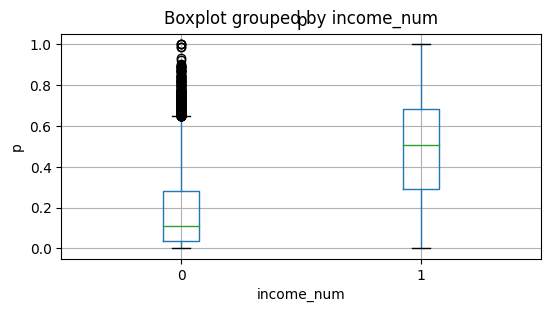

In [ ]:
# We plot a boxplot to see the distribution of the estimated odds for both response values
df_train.boxplot(column='p', by = 'income_num')
plt.ylabel('p')
plt.show()

# Qualitatively from both of these plots it seems that the model does capture the income effects in the training set

In [ ]:
# Measure statistical accuracy, MCC, precision, and recall
# First - Extract True Positives, False Positive, False Negatives, True Negatives from confusion matrix
conf_mat = m.pred_table()
tn, fp, fn, tp = conf_mat.flatten()

# Calculate Statistical Accuracy
acc = (tp+tn) / np.sum(conf_mat)
print("Accuracy of the model on training data is: %1.2f" % acc)

# Calculate MCC
mcc = (tp*tn-fp*fn)/np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
print("Matthews correlation coefficient between the estimates and the true response is: %1.2f" % mcc)
precision = tp/(tp+fp)
recall = tp/(tp+fn)

print("Model's precision is %1.2f and its recall is %1.2f" % (precision,recall))
spec = tn / (tn + fp)
f1 = 2*precision*recall / (precision + recall)

print ("Model's specificity is %1.2f and it's F1-score is %1.2f" % (spec, f1))

# We observe reasonably good accuracy, positive MCC, however, recall is only 51%, 
# suggesting that the model misses a lot of the >50k income individuals (a lot of false negatives)
# Since the dataset consists of a majority of <50k income individuals, 
# if our goal is to identify more of these individuals (say to target them in a sales campaign), 
# we would like to reduce this form of error

Accuracy of the model on training data is: 0.80
Matthews correlation coefficient between the estimates and the true response is: 0.44
Model's precision is 0.63 and its recall is 0.51
Model's specificity is 0.90 and it's F1-score is 0.56


In [ ]:
# Discrimination threshold optimization
#Illustrates the relationship between the true positive rate (TPR) (sensitivity) and the false positive rate (FPR)
ths = np.arange(0., 1.0, 0.025)

# Containers
sensitivity = []
specificity = []
accuracy = []
matthews = []

# Main loop
for th in ths:
    # Generate estimates
    conf_mat = m.pred_table(threshold=th)
    
    # Extract TN, FP, ...
    tn, fp, fn, tp = conf_mat.flatten()
    
    # Calculate sensitivity and specificity
    sens = (1. * tp) / (tp + fn)
    spec = (1. * tn) / (tn + fp)    
    
    # Calculate ACC and MCC
    acc = (tp + tn) / np.sum(conf_mat)
    mcc = (tp * tn - fp * fn)/np.sqrt((tp + fp)*(tp + fn)*(tn + fp)*(tn + fn))    

    # Add to containers
    sensitivity.append(sens)
    specificity.append(spec)
    accuracy.append(acc)
    matthews.append(mcc)

# Bind all the numbers together
roc = pd.DataFrame({'discret_thr' : ths, 
                    'sensitivity' : sensitivity, 
                    'specificity' : specificity,
                    '_specificity' : [1 - x for x in specificity],
                    'accuracy' : accuracy, 
                    'matthews' : matthews})

# Sort by 1 - specificity so we can plot it easily
roc = roc.sort_values(by = "_specificity")

# Display table for debugging purposes
roc

,discret_thr,sensitivity,specificity,_specificity,accuracy,matthews
39,0.975,0.055853,0.999735,0.000265,0.76720,0.204154
38,0.950,0.067543,0.999735,0.000265,0.77008,0.225298
37,0.925,0.087839,0.999682,0.000318,0.77504,0.257785
36,0.900,0.102127,0.999575,0.000425,0.77848,0.278101
35,0.875,0.110570,0.999045,0.000955,0.78016,0.286500
34,0.850,0.118850,0.998567,0.001433,0.78184,0.294879
33,0.825,0.125832,0.998089,0.001911,0.78320,0.301394
32,0.800,0.132002,0.997399,0.002601,0.78420,0.305591
31,0.775,0.137685,0.996815,0.003185,0.78516,0.309778
30,0.750,0.146939,0.993790,0.006210,0.78516,0.306239


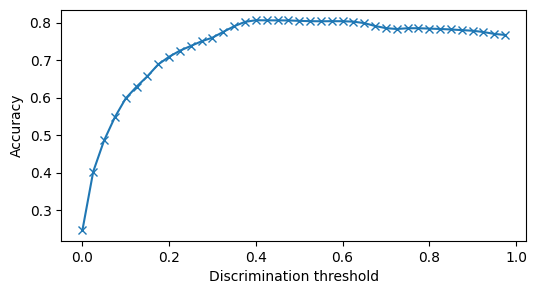

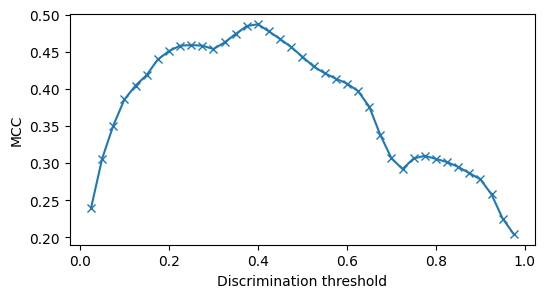

In [ ]:
plt.plot(roc.discret_thr, roc.accuracy, 'x-')
plt.xlabel('Discrimination threshold')
plt.ylabel('Accuracy')
plt.show()

plt.plot(roc.discret_thr, roc.matthews, 'x-')
plt.xlabel('Discrimination threshold')
plt.ylabel('MCC')
plt.show()

# We observe that both accuracy and MCC are maximized at 0.40
# From the table, we can see that the midpoint threshold results in almost half of the >50k individuals
# being classified incorrectly (false negatives), even though overall accuracy is high due to the large number
# of <50k individuals

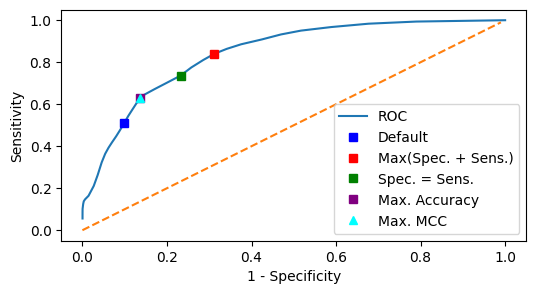

In [ ]:
# We plot the Receiver Operating Characteristic to get a better sense of the tradeoffs for different choices of 
# threshold

# Where threshold equal 0.5 
roc = roc.sort_values(by = "_specificity")
idx_default_th = np.where(roc.discret_thr == 0.5)[0][0]

# Max sum of spec and sens
idx_youdensj = np.argmax(roc.sensitivity + roc.specificity)

 # Balanced spec and sens
idx_ballance = np.argmin(np.abs(roc.sensitivity - roc.specificity))

# Max accuracy
idx_maxacc = np.where(roc.accuracy==max(roc.accuracy))[0][0]

# Max MCC
idx_maxmcc = np.where(roc.matthews==max(roc.matthews))[0][0]

plt.plot(roc._specificity, roc.sensitivity, label = 'ROC')

plt.plot(np.arange(0., 1., 0.01), 
         np.arange(0., 1., 0.01), 
         '--')

plt.plot(roc.iloc[idx_default_th,3], 
         roc.iloc[idx_default_th,1], 
         's', color = 'blue',
         label = 'Default')

plt.plot(roc.iloc[idx_youdensj,3], 
         roc.iloc[idx_youdensj,1], 
         's', color = 'red',
         label = 'Max(Spec. + Sens.)')

plt.plot(roc.iloc[idx_ballance,3], 
         roc.iloc[idx_ballance,1], 
         's', color = 'green', 
         label = 'Spec. = Sens.')

plt.plot(roc.iloc[idx_maxacc,3], 
         roc.iloc[idx_maxacc,1], 
         's', color = 'purple',
         label = 'Max. Accuracy')

plt.plot(roc.iloc[idx_maxmcc,3], 
         roc.iloc[idx_maxmcc,1], 
         '^', color = 'cyan', 
         label = 'Max. MCC')

plt.legend(loc = 4)
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.show()

In [ ]:
print("Default Threshold: ",roc.iloc[idx_default_th,0])
print("Optimal Threshold: ",roc.iloc[idx_youdensj,0])
print("Balanced Threshold: ",roc.iloc[idx_ballance,0])
print("Max Accuracy Threshold: ",roc.iloc[idx_maxacc,0])
print("Max MCC Threshold: ",roc.iloc[idx_maxmcc,0])

# The point on the ROC curve that is closest to the error-free point (0,1) is the point where the sum of sensitivity and 
# specificity is maximal. This is the optimal threshold. Thus, by choosing this threshold, we sacrifice some specificity
# (have more false positives) but we are closest to being error free in terms of considering both false positives and false
# negatives

Default Threshold:  0.5
Optimal Threshold:  0.225
Balanced Threshold:  0.30000000000000004
Max Accuracy Threshold:  0.4
Max MCC Threshold:  0.4


In [ ]:
# The AUC is equal to the probability that a model will estimate a randomly chosen binary response better than 
# a random estimator.
auc = np.trapz(y = roc.sensitivity, x = roc._specificity)
print ("Area under ROC curve = %1.2f" % auc)

# Being >0.5 gives us confidence that the model performs better than random

Area under ROC curve = 0.84


In [ ]:
# Youden's J is a measure characterizing to what extent the sensitivity and specificity of the model 
# can be maximized by optimal choice of the threshold (what we selected as our threshold)
J = max(roc.sensitivity + roc.specificity - 1)
print ('Youden\'s J = %1.2f' % J)

Youden's J = 0.53


In [ ]:
# Testing Data - incorporate threshold adjustments
# Creating predictions based on model
df_test.loc[:,'p'] = m.predict(df_test[predictors_clean2])
df_test.loc[:,'yhat'] = (df_test.p > 0.225) * 1
df_test.yhat.value_counts()

# Comparing predictions against actual values
print("Testing")
print(pd.crosstab(df_test.income_num, df_test.yhat))
print("-------------------------------------\n")

Testing
yhat            0     1
income_num             
0           10438  4735
1             778  4271
-------------------------------------



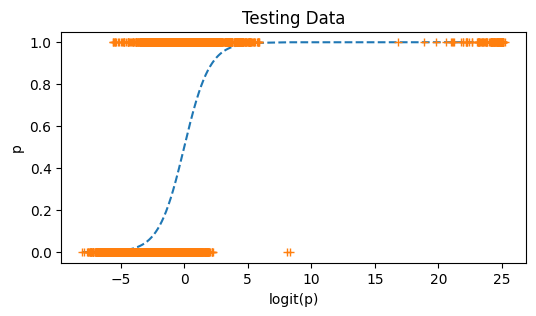

In [ ]:
# Testing Data
df_test_plot = df_test.sort_values(by = ['p'], axis = 0)
plt.plot(logit(df_test_plot.p), df_test_plot.p, '--')
plt.plot(logit(df_test_plot.p), df_test_plot.income_num, '+')
plt.xlabel('logit(p)')
plt.ylabel('p')
plt.title('Testing Data')
plt.show()

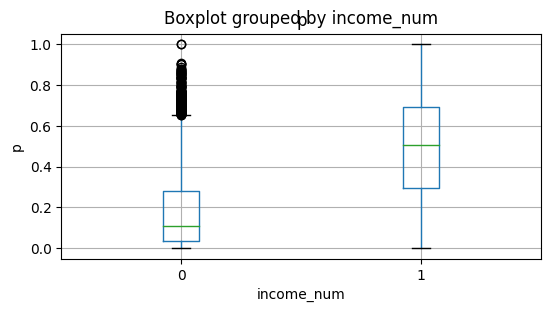

In [ ]:
df_test.boxplot(column='p', by = 'income_num')
plt.ylabel('p')
plt.show()

In [ ]:
# Measure statistical accuracy, MCC, precision, and recall on testing data
print("Testing Data Results:")

y_pred = df_test.yhat

#extract the TP, FP, FN and TP.
tn = np.count_nonzero((y_pred.to_numpy() == y_test.to_numpy()) * (y_pred.to_numpy() == 0))
tp = np.count_nonzero((y_pred.to_numpy() == y_test.to_numpy()) * (y_pred.to_numpy() == 1))
fn = np.count_nonzero((y_pred.to_numpy() != y_test.to_numpy()) * (y_pred.to_numpy() == 0))
fp = np.count_nonzero((y_pred.to_numpy() != y_test.to_numpy()) * (y_pred.to_numpy() == 1))

# Calculate Statistical Accuracy
acc = (tp+tn) / np.sum(conf_mat)
print("Accuracy of the model on testing data is: %1.2f" % acc)

# Calculate MCC
mcc = (tp*tn-fp*fn)/np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
print("Matthews correlation coefficient between the estimates and the true response is: %1.2f" % mcc)

precision = tp/(tp+fp)
recall = tp/(tp+fn)
print("Model's precision is %1.2f and its recall is %1.2f" % (precision,recall))

spec = tn / (tn + fp)
f1 = 2*precision*recall / (precision + recall)
print ("Model's specificity is %1.2f and it's F1-score is %1.2f" % (spec, f1))

# We observe that the accuracy of the model is lower out of sample (and following the threshold adjustment)
# But it is still correct roughly 60% of the time
# MCC = 0.46 suggests that we are much better than random
# The number of false positives has increased, as expected, however, recall has improved to 0.85, suggesting
# that the proportion of false negatives is low. We observe that the F1 score is slightly higher

Testing Data Results:
Accuracy of the model on testing data is: 0.59
Matthews correlation coefficient between the estimates and the true response is: 0.46
Model's precision is 0.47 and its recall is 0.85
Model's specificity is 0.69 and it's F1-score is 0.61


Determining Accuracy for Logistic Regression in addition to other classifier models based on different inputs using One Hot Encoding.  One input seems to have an accuracy of 76% while eight inputs has an accuracy of 83%, similar to above.

In [ ]:
# Analysis of Multiple Models

def extract_x_input_and_y_output_from_dataset(x_columns, y_column):

    # x_columns: independent variables input
    # y_column:  dependent variable output
    
    # Create a copy of the independent variable column list.
    
    x_and_y_columns = x_columns.copy()
    
    # Append the dependent column to the total list.
    
    x_and_y_columns.append(y_column)
 
    # Create a dataframe of the total list of columns.
    
    my_df = df.loc[:, x_and_y_columns]

    # Create the x (input) and y (output) variables.
    
    x = my_df.loc[:, :x_columns[-1]].values
    y = my_df.loc[:, y_column].values
    
    return x, y


In [ ]:
from abc import ABC, abstractmethod

# Abstract Class classifier_model

class classifier_model(ABC):
    
    # Constructor.
    
    def __init__(self, model_name):
        
        self.model_name = model_name
        
    
    # predict_for_single_input

    def predict_for_single_input(self, x_input_list):
        
        # Create an empty list for x and append the x input list.
        
        x = []
        x.append(x_input_list)
   
        # Transform the input based on the One Hot Encoding already done during the
        # training phase.
        
        x_new = self.ohe.transform(x)

        # If the model is a Gaussian Naive Bayes model, convert the
        # OHE transformation from a sparse array to a dense array.
        
        if (self.model_name == 'Gaussian Naive Bayes'):
            x_new = x_new.toarray()

        # Make the prediction.
        
        y_new = self.model.predict(x_new)

        # Perform an inverse transformation of the prediction to get its
        # proper label (e.g., <50K)
        
        predictions_test = self.le.inverse_transform(y_new)
        print("For an input set of: ", x_input_list, "the model predicts income to be ", predictions_test[0])
        
    
    # evaluate_classifier_model
    
    def evaluate_classifier_model(self, x, y, training_test_size=10000, _debug=False):

        # Split the data into training and test data.

        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=training_test_size, random_state=1)

        # Encode the independent training data using One Hot Encoder.

        ohe = OneHotEncoder()
        ohe.fit(x_train)

        # Store the One Hot Coding variable as an instance attribute.
        
        self.ohe = ohe

        # Transform the input training and test data using One Hot Encoder.

        x_train = ohe.transform(x_train)
        x_test = ohe.transform(x_test)

        # Encode the dependent variable strings to the numeric using LabelEncoder.

        le = LabelEncoder()
        le.fit(y_train)

        # Store the Label Encoder variable as an instance attribute.

        self.le = le

        # Transform the output training and test data using Label Encoder.

        y_train = le.transform(y_train)
        y_test = le.transform(y_test)

        # Fit the training data using the instantiated model and get the dependent 
        # variable predictions.
        
        y_pred = self.fit_model(x_test, x_train, y_train)
                  
        # Reshape the data and create the prediction results.

        y_test = np.reshape(y_test, (y_test.size,))
        prediction_results = (y_pred == y_test)

        if _debug: print (y_test)
        if _debug: print (prediction_results)

        # Count the number of correct predictions.

        correct_predictions = np.count_nonzero(prediction_results)

        # Calculate the model accuracy.

        accuracy = round((correct_predictions / training_test_size) * 100, 2)
        print ("Model: ", self.model_name)
        #print ("\tCorrect predictions =", correct_predictions, "/", training_test_size, 
               #"Incorrect predictions =", (training_test_size - correct_predictions), 
               #"Accuracy = ", accuracy, "%")

        #extract the TP, FP, FN and TP.
        tn = np.count_nonzero((y_pred == y_test) * (y_pred == 0))
        tp = np.count_nonzero((y_pred == y_test) * (y_pred == 1))
        fn = np.count_nonzero((y_pred != y_test) * (y_pred == 0))
        fp = np.count_nonzero((y_pred != y_test) * (y_pred == 1))

        if _debug: 
            print("Tn of the model is:" , tn)
            print("Tp of the model is:" , tp)
            print("Fn of the model is:" , fn)
            print("Fp of the model is:" , fp)
        
        acc = (tp + tn) / training_test_size
        print ("Accuraccy of the model is: %1.2f" % acc)

        mcc = (tp * tn - fp * fn)/np.sqrt((tp + fp)*(tp + fn)*(tn + fp)*(tn + fn))
        print ("Mathews correlation coefficient between the estimates and the true response is: %1.2f" % mcc)

        if (tp + fp !=0):
            prc = tp / (tp + fp)
        else:
            prc = float('inf')
        if (tp + fn !=0):
            rec = tp / (tp + fn)
        else:
            rec = float('inf')
            
        print ("Model's precision is %1.2f and it's recall is %1.2f" % (prc, rec))
        print("---------------------------------------\n")

        #spec = tn / (tn + fp)
        #f1 = 2*prc*rec / (prc + rec)
        #print ("Model's specificity is %1.2f and it's F1-score is %1.2f" % (spec, f1))
        
        # Print the Actual vs Predicted dataframe prediction results.
        if _debug: print (pd.DataFrame({'Actual' : y_test, 'Predicted' : prediction_results}))

    
    @abstractmethod
    def fit_model(self, x_test, x_train, y_train):
        
        # Return nil for the abstract method.
        
        return nil
    

# Concrete Class logistic_regression_model

class logistic_regression_model(classifier_model):
    
    def fit_model(self, x_test, x_train, y_train):
        
        # Fit the training data using the Logistic Regression model.

        lrm = LogisticRegression(random_state=0)
        lrm.fit(x_train, y_train)
        
        # Store the model variable as an instance attribute.
        
        self.model = lrm

        # Create the y predictions (output) based on the test data (input).

        return lrm.predict(x_test)


# Concrete Class knn_model

class knn_model(classifier_model):
    
    def fit_model(self, x_test, x_train, y_train):
        
        # Fit the training data using the KNN model.  Note that if the number of neighbours
        # is small (like 2), the accuracy is lower.

        neighbours = 15
        knn = KNeighborsClassifier(n_neighbors=neighbours)
        knn.fit(x_train, y_train.ravel())
        
        # Store the model variable as an instance attribute.
        
        self.model = knn

        # Create the y predictions (output) based on the test data (input).

        return knn.predict(x_test)
    
    
# Concrete Class gaussian_naive_bayes_model

class gaussian_naive_bayes_model(classifier_model):
    
    def fit_model(self, x_test, x_train, y_train):
        
        # Fit the training data using the Gaussian Naive Bayes model.
        
        gnb = GaussianNB()
        gnb.fit(x_train.toarray(), y_train)

        # Store the model variable as an instance attribute.
        
        self.model = gnb

        # Create the y predictions (output) based on the test data (input).

        return gnb.predict(x_test.toarray())
    
    
# Concrete class decision_tree_model

class decision_tree_model(classifier_model):
    
    def fit_model(self, x_test, x_train, y_train):
        
        # Fit the training data using the Decision Tree Classifier model.
        
        dtc = DecisionTreeClassifier()
        dtc.fit(x_train, y_train.ravel())

        # Store the model variable as an instance attribute.
        
        self.model = dtc

        # Create the y predictions (output) based on the test data (input).

        return dtc.predict(x_test)
        
        
# Concrete class svc_model

class svc_model(classifier_model):
    
    def fit_model(self, x_test, x_train, y_train):
        
        # Fit the training data using the Decision Tree Classifier model.
        
        svc = SVC()
        svc.fit(x_train, y_train.ravel())

        # Store the model variable as an instance attribute.
        
        self.model = svc

        # Create the y predictions (output) based on the test data (input).

        return svc.predict(x_test)


In [ ]:
# Create the classifier model classes.

lrm = logistic_regression_model("Logistic Regression")
knn = knn_model("KNN")
nbb = gaussian_naive_bayes_model("Gaussian Naive Bayes")
dtm = decision_tree_model("Decision Tree Classifier")
svm = svc_model("Support Vector Machines")

# Note: Support Vector Machines model has a very similar accuracy as Logistic Regression 
# but takes a very long time to execute.  Set the following boolean to True to see the results.

run_svm = False  

# Model accuracy for one input, training data set of 1000.

print("One input, training data set: 1,000")
print("-----------------------------------\n")

x, y = extract_x_input_and_y_output_from_dataset(['employment_type'], 'income')
lrm.evaluate_classifier_model(x, y, 1000)
knn.evaluate_classifier_model(x, y, 1000)
nbb.evaluate_classifier_model(x, y, 1000)
dtm.evaluate_classifier_model(x, y, 1000)
if run_svm: svm.evaluate_classifier_model(x, y, 1000)


# Model accuracy for two inputs, training data set of 1000.

print("\nTwo inputs, training data set: 1,000")
print("------------------------------------\n")

x, y = extract_x_input_and_y_output_from_dataset(['age_group', 'marital_status'], 'income')
lrm.evaluate_classifier_model(x, y, 1000)
knn.evaluate_classifier_model(x, y, 1000)
nbb.evaluate_classifier_model(x, y, 1000)
dtm.evaluate_classifier_model(x, y, 1000)
if run_svm: svm.evaluate_classifier_model(x, y, 1000)


# Model accuracy for two inputs, training data set of 15,000.

print("\nTwo inputs, training data set: 15,000")
print("-------------------------------------\n")

x, y = extract_x_input_and_y_output_from_dataset(['age_group', 'marital_status'], 'income')
lrm.evaluate_classifier_model(x, y, 15000)
knn.evaluate_classifier_model(x, y, 15000)
nbb.evaluate_classifier_model(x, y, 15000)
dtm.evaluate_classifier_model(x, y, 15000)
if run_svm: svm.evaluate_classifier_model(x, y, 15000)


# Model accuracy for eight inputs, training data set of 1000.

print("\nEight inputs, training data set: 1,000")
print("-------------------------------------\n")

x, y = extract_x_input_and_y_output_from_dataset(['age_group', 'marital_status', 'employment_type', 'region', 'workclass', 'sex', 'race', 'education'], 'income')
lrm.evaluate_classifier_model(x, y, 1000)
knn.evaluate_classifier_model(x, y, 1000)
nbb.evaluate_classifier_model(x, y, 1000)
dtm.evaluate_classifier_model(x, y, 1000)
if run_svm: svm.evaluate_classifier_model(x, y, 1000)


# Model accuracy for eight inputs, training data set of 15,000.

print("\nEight inputs, training data set: 15,000")
print("---------------------------------------\n")

x, y = extract_x_input_and_y_output_from_dataset(['age_group', 'marital_status', 'employment_type', 'region', 'workclass', 'sex', 'race', 'education'], 'income')
lrm.evaluate_classifier_model(x, y, 15000)
knn.evaluate_classifier_model(x, y, 15000)
nbb.evaluate_classifier_model(x, y, 15000)
dtm.evaluate_classifier_model(x, y, 15000)
if run_svm: svm.evaluate_classifier_model(x, y, 15000)


# Model accuracy for eight inputs, training data set of 25,000.

print("\nEight inputs, training data set: 25,000")
print("---------------------------------------\n")

x, y = extract_x_input_and_y_output_from_dataset(['age_group', 'marital_status', 'employment_type', 'region', 'workclass', 'sex', 'race', 'education'], 'income')
lrm.evaluate_classifier_model(x, y, 25000)
knn.evaluate_classifier_model(x, y, 25000)
nbb.evaluate_classifier_model(x, y, 25000)
dtm.evaluate_classifier_model(x, y, 25000)
if run_svm: svm.evaluate_classifier_model(x, y, 25000)



One input, training data set: 1,000
-----------------------------------

Model:  Logistic Regression
Accuraccy of the model is: 0.76
Mathews correlation coefficient between the estimates and the true response is: nan
Model's precision is inf and it's recall is 0.00
---------------------------------------

Model:  KNN
Accuraccy of the model is: 0.76
Mathews correlation coefficient between the estimates and the true response is: nan
Model's precision is inf and it's recall is 0.00
---------------------------------------

Model:  Gaussian Naive Bayes
Accuraccy of the model is: 0.41
Mathews correlation coefficient between the estimates and the true response is: 0.19
Model's precision is 0.28 and it's recall is 0.94
---------------------------------------

Model:  Decision Tree Classifier
Accuraccy of the model is: 0.76
Mathews correlation coefficient between the estimates and the true response is: nan
Model's precision is inf and it's recall is 0.00
---------------------------------------


Accuracy Comparisons: the models have similar, lower accuracies when only two features in the input set are used on a training set of 1,000 records compared to when there are eight features in the input set using a training set of 15,000 records.  The Logistic Regression model consistently has the higher accuracy (83%) whereas the Guassian Naive Bayes has a much lower accuracy (53%)

Hypothesis:
- Ages within the range of 25-45 would likely be correlated with income over $50k

- Higher education level attained would be correlated with an income over $50K

- Specific occupations such prof_specialty and exec_managerial would be associated with higher income

- Given that this data set is from 1994, our assumption was that we will see a higher proportion of males in the above $50k income group

- Capital Gain would be higher and Capital Loss would be lower in the above $50k income group

- We would see a correlation between a high number of hours per week and the higher income group


In [ ]:
# Based on the hypothesis, conduct single tests to see if the model returns the correct prediction.

print ("Hypothesis Testing")
print ("------------------\n")

# Instantiate a logistic regression model.

lrm = logistic_regression_model("Logistic Regression")

# Hypothesis Test Case 1
#
# Extract several features from the data set.
#
# - Age Group
# - Marital Status
# - Employment Type
# - Sex

x_feature_list = ['age_group', 'marital_status', 'employment_type', 'sex']
print ("Using features: ", x_feature_list, "\n")
x, y = extract_x_input_and_y_output_from_dataset(x_feature_list, 'income')

# Train, test and evaluate the model.

lrm.evaluate_classifier_model(x, y, 15000)

# The following input set should result in a classification of > 50K

x_input_list = ['Middle Age', 'Married-civ-spouse', 'Over Employed', 'Male']
lrm.predict_for_single_input(x_input_list)
print("The expected result is: >50K\n")

# The following input set should result in a classification of <= 50K

x_input_list = ['Middle Age', 'Married-civ-spouse', 'Part Time', 'Female']
lrm.predict_for_single_input(x_input_list)
print("The expected result is: <=50K\n")



# Hypothesis Test Case 2
#
# Extract several features from the data set.
#
# - Age Group
# - Education
# - Employment Type
# - Sex
# - Occupation

x_feature_list = ['age_group', 'education', 'employment_type', 'sex', 'occupation']
print ("Using features: ", x_feature_list, "\n")
x, y = extract_x_input_and_y_output_from_dataset(x_feature_list, 'income')

# Train, test and evaluate the model.

lrm.evaluate_classifier_model(x, y, 15000)

# The following input set should result in a classification of > 50K

x_input_list = ['Middle Age', 'Doctorate', 'Over Employed', 'Male', 'prof']
lrm.predict_for_single_input(x_input_list)
print("The expected result is: >50K\n")

# The following input set should result in a classification of <= 50K

x_input_list = ['Teenager', 'HS-grad', 'Part Time', 'Male', 'caretaker']
lrm.predict_for_single_input(x_input_list)
print("The expected result is: <=50K\n")

# The "Differentiator"
# The following input set should result in a hypothesis of <= 50K
# With an 80% accuracy, it does

x_input_list = ['Middle Age', 'Doctorate', 'Part Time', 'Male', 'caretaker']
lrm.predict_for_single_input(x_input_list)
print("The expected result is: <=50K\n")


Hypothesis Testing
------------------

Using features:  ['age_group', 'marital_status', 'employment_type', 'sex'] 

Model:  Logistic Regression
Accuraccy of the model is: 0.77
Mathews correlation coefficient between the estimates and the true response is: 0.37
Model's precision is 0.55 and it's recall is 0.48
---------------------------------------

For an input set of:  ['Middle Age', 'Married-civ-spouse', 'Over Employed', 'Male'] the model predicts income to be  >50K
The expected result is: >50K

For an input set of:  ['Middle Age', 'Married-civ-spouse', 'Part Time', 'Female'] the model predicts income to be  <=50K
The expected result is: <=50K

Using features:  ['age_group', 'education', 'employment_type', 'sex', 'occupation'] 

Model:  Logistic Regression
Accuraccy of the model is: 0.80
Mathews correlation coefficient between the estimates and the true response is: 0.41
Model's precision is 0.66 and it's recall is 0.42
---------------------------------------

For an input set of:  

In [ ]:
# Based on the hypothesis, conduct single tests to see if the model returns the correct prediction.

print ("Hypothesis Testing")
print ("------------------\n")

# Instantiate a Gaussian Naive Bayes model.

nbb = gaussian_naive_bayes_model("Gaussian Naive Bayes")

# Hypothesis Test Case 1
#
# Extract several features from the data set.
#
# - Age Group
# - Marital Status
# - Employment Type
# - Sex

x_feature_list = ['age_group', 'marital_status', 'employment_type', 'sex']
print ("Using features: ", x_feature_list, "\n")
x, y = extract_x_input_and_y_output_from_dataset(x_feature_list, 'income')

# Train, test and evaluate the model.

nbb.evaluate_classifier_model(x, y, 15000)

# The following input set should result in a hypothesis of > 50K

x_input_list = ['Middle Age', 'Married-civ-spouse', 'Over Employed', 'Male']
nbb.predict_for_single_input(np.array(x_input_list))
print("The expected result is: >50K\n")

# The following input set should result in a hypothesis of <= 50K

x_input_list = ['Middle Age', 'Married-civ-spouse', 'Part Time', 'Female']
nbb.predict_for_single_input(x_input_list)
print("The expected result is: <=50K\n")



# Hypothesis Test Case 2
#
# Extract several features from the data set.
#
# - Age Group
# - Education
# - Employment Type
# - Sex
# - Occupation

x_feature_list = ['age_group', 'education', 'employment_type', 'sex', 'occupation']
print ("Using features: ", x_feature_list, "\n")
x, y = extract_x_input_and_y_output_from_dataset(x_feature_list, 'income')

# Train, test and evaluate the model.

nbb.evaluate_classifier_model(x, y, 15000)


# The following input set should result in a hypothesis of > 50K

x_input_list = ['Middle Age', 'Doctorate', 'Over Employed', 'Male', 'prof']
nbb.predict_for_single_input(x_input_list)
print("The expected result is: >50K\n")

# The following input set should result in a hypothesis of <= 50K

x_input_list = ['Teenager', 'HS-grad', 'Part Time', 'Male', 'caretaker']
nbb.predict_for_single_input(x_input_list)
print("The expected result is: <=50K\n")

# The "Differentiator"
# The following input set should result in a hypothesis of <= 50K
# With an accuracy of 51%, it does not

x_input_list = ['Middle Age', 'Doctorate', 'Part Time', 'Male', 'caretaker']
nbb.predict_for_single_input(x_input_list)
print("The expected result is: <=50K\n")


Based on the hypothesis and using a Logistic Regression model with 77-80% accuracy and a 0.70 precision, testing individual input samples (e.g., a person who is middle age, has a doctorate, works more than full-time, is male and is a professional as well as a person who is a teenager, high-school grad, works part-time, is male and is a caretaker) results in the correct classification prediction.  

However, using a Gaussian Naive Bayes model with an accuracy of 53% and a 0.34 precision, will miss the classification prediction of a 'borderline' case where a person has a combination of strong predictors and weak predictors (e.g., middle age, has a doctorate and is male but works part-time as a caretaker).